# Environment Setup

In [1]:
# REMEMBER RUN THIS CODE AND IT WILL RESTART THE KERNEL
# RUN THIS CELL AGAIN AFTER THE RESTART AND IT WILL SAY "✅ Environment is Ready!"

import os
import sys

# 1. Define the "Check File"
DONE_FLAG = "/content/env_fixed.flag"

if not os.path.exists(DONE_FLAG):
    print("🔧 Fixing Environment & Installing Model Libraries...")

    # 2. Install uv (Instant)
    !pip install -q uv

    !uv pip install --system --quiet \
        "numpy<2.0.0" \
        "pandas<2.2.0" \
        "pyarrow>=14.0.0" \
        transformers \
        timm \
        faiss-gpu-cu12 \
        duckdb \
        mlflow \
        dagshub \
        psutil \
        webdataset

    # 4. Mark as done
    !touch {DONE_FLAG}

    # 5. AUTOMATIC RESTART
    print("🔄 Restarting Kernel to load new libraries... (Please wait a moment)")
    os.kill(os.getpid(), 9)

else:
    # After the restart, this block runs.
    import numpy as np
    import pandas as pd
    print("✅ Environment is Ready!")

✅ Environment is Ready!


In [2]:
# ==========================================
# 1. STANDARD LIBRARY & SYSTEM IMPORTS
# ==========================================
import os
import sys
import gc
import time
import shutil
import sqlite3
import psutil
import resource
import gzip
import csv
import glob
import pickle
import functools
import subprocess
import urllib
import math
import hashlib
import tarfile
import ast
from collections import Counter
from pathlib import Path

# ==========================================
# 2. TYPING & CONCURRENCY
# ==========================================
from typing import List, Dict, Tuple, Optional, Any
import concurrent.futures
from concurrent.futures import ThreadPoolExecutor
from io import BytesIO

# ==========================================
# 3. DATA SCIENCE & DATABASES
# ==========================================
import numpy as np
import pandas as pd
import duckdb
import pyarrow as pa
import pyarrow.parquet as pq

# ==========================================
# 4. PYTORCH & DEEP LEARNING
# ==========================================
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms
import webdataset as wds

# ==========================================
# 5. HUGGING FACE & MODEL ARCHITECTURES
# ==========================================
import transformers
from transformers import (
    AutoImageProcessor,
    AutoModel,
    CLIPModel,
    CLIPProcessor,
    SiglipModel,
    SiglipProcessor
)
from datasets import load_dataset
from huggingface_hub import list_repo_files, hf_hub_url

# ==========================================
# 6. IMAGE PROCESSING & VISUALIZATION
# ==========================================
from PIL import Image
import matplotlib.pyplot as plt

# ==========================================
# 7. VECTOR SEARCH & TRACKING
# ==========================================
import faiss
import mlflow
import dagshub

# ==========================================
# 8. UTILITIES & NETWORK
# ==========================================
from tqdm.auto import tqdm
import requests

# ==========================================
# 9. COLAB SETUP
# ==========================================
try:
    from google.colab import drive, userdata, files
except ImportError:
    print("Google Colab specific libraries not found. Skipping.")

In [3]:
drive.mount('/content/drive',force_remount = True)

Mounted at /content/drive


# Model Factory

In [4]:
class BaseEmbeddingModel:
    """Standard Interface for all models"""
    def __init__(self, device=None):
        self.device = device if device else ("cuda" if torch.cuda.is_available() else "cpu")
        self.device = torch.device(self.device)
        self.requires_text = False # Default to False for vision-only models

    def get_transforms(self):
        """Returns the torchvision-compatible transform for the dataset"""
        raise NotImplementedError

    def embed_image(self, image_tensor):
        """Accepts (B, C, H, W) tensor, returns (B, D) normalized embedding"""
        raise NotImplementedError

    def embed_text(self, text_list):
        """Optional: Accepts list of strings, returns (B, D) normalized embedding"""
        raise NotImplementedError("This model does not support text embeddings.")

    def embed_multimodal(self, image_tensor, text_list):
        """Optional: Combines image and text into a single unified embedding"""
        raise NotImplementedError("This model does not support multimodal embeddings.")

# ==========================================
# 1. ResNet50 (The Baseline)
# ==========================================
class ResNetEmbedder(BaseEmbeddingModel):
    def __init__(self, device=None):
        super().__init__(device)
        self.requires_text = False
        print(f"Loading ResNet50 on {self.device}...")
        weights = models.ResNet50_Weights.DEFAULT
        backbone = models.resnet50(weights=weights)
        self.model = nn.Sequential(*(list(backbone.children())[:-1]))
        self.model.to(self.device)
        self.model.eval()
        self.transforms = weights.transforms()

    def get_transforms(self):
        return self.transforms

    def embed_image(self, image_tensor):
        with torch.no_grad():
            features = self.model(image_tensor.to(self.device))
            features = features.flatten(1)
            return torch.nn.functional.normalize(features, p=2, dim=1)

# ==========================================
# 2. ConvNeXt (Modern CNN)
# ==========================================
class ConvNeXtEmbedder(BaseEmbeddingModel):
    def __init__(self, version='base', device=None):
        super().__init__(device)
        self.requires_text = False
        print(f"Loading ConvNeXt-{version} on {self.device}...")

        if version == 'base':
            weights = models.ConvNeXt_Base_Weights.DEFAULT
            self.model = models.convnext_base(weights=weights)
        elif version == 'tiny':
            weights = models.ConvNeXt_Tiny_Weights.DEFAULT
            self.model = models.convnext_tiny(weights=weights)
        else:
            raise ValueError("Supported versions: 'base', 'tiny'")

        self.model.classifier = nn.Identity()
        self.model.to(self.device)
        self.model.eval()
        self.transforms = weights.transforms()

    def get_transforms(self):
        return self.transforms

    def embed_image(self, image_tensor):
        with torch.no_grad():
            features = self.model(image_tensor.to(self.device))
            features = features.flatten(1)
            return torch.nn.functional.normalize(features, p=2, dim=1)

# ==========================================
# 3. DINOv2 (Visual King)
# ==========================================
class DINOv2Embedder(BaseEmbeddingModel):
    def __init__(self, size='base', device=None):
        super().__init__(device)
        self.requires_text = False
        model_map = {
            'small': 'facebook/dinov2-small',
            'base':  'facebook/dinov2-base',
            'large': 'facebook/dinov2-large',
            'giant': 'facebook/dinov2-giant'
        }

        if size not in model_map:
            raise ValueError(f"Unknown DINOv2 size: {size}. Choose from {list(model_map.keys())}")

        model_id = model_map[size]
        print(f"Loading DINOv2 ({model_id}) on {self.device}...")

        self.processor = AutoImageProcessor.from_pretrained(model_id)
        self.model = AutoModel.from_pretrained(model_id).to(self.device)
        self.model.eval()

    def get_transforms(self):
        def hf_transform(img):
            return self.processor(images=img, return_tensors="pt")['pixel_values'].squeeze(0)
        return hf_transform

    def embed_image(self, image_tensor):
        with torch.no_grad():
            outputs = self.model(pixel_values=image_tensor.to(self.device))
            features = outputs.last_hidden_state[:, 0, :]
            return torch.nn.functional.normalize(features, p=2, dim=1)

# ==========================================
# 4. SigLIP (Concept King)
# ==========================================
class SigLIPEmbedder(BaseEmbeddingModel):
    def __init__(self, model_id="google/siglip-so400m-patch14-384", device=None):
        super().__init__(device)
        self.requires_text = True
        print(f"Loading SigLIP ({model_id}) on {self.device}...")
        self.model = SiglipModel.from_pretrained(model_id).to(self.device)
        self.processor = SiglipProcessor.from_pretrained(model_id)
        self.model.eval()

    def get_transforms(self):
        def hf_transform(img):
            return self.processor(images=img, return_tensors="pt")['pixel_values'].squeeze(0)
        return hf_transform

    def _extract_tensor(self, features):
        """Safely extracts the tensor whether HF returns an object or a raw tensor."""
        if isinstance(features, torch.Tensor):
            return features
        if hasattr(features, 'pooler_output') and features.pooler_output is not None:
            return features.pooler_output
        if hasattr(features, 'image_embeds') and features.image_embeds is not None:
            return features.image_embeds
        if hasattr(features, 'text_embeds') and features.text_embeds is not None:
            return features.text_embeds
        if hasattr(features, 'last_hidden_state'):
            return features.last_hidden_state[:, 0, :]
        return features[0]

    def embed_image(self, image_tensor):
        with torch.no_grad():
            features = self.model.get_image_features(pixel_values=image_tensor.to(self.device))
            features = self._extract_tensor(features)
            return torch.nn.functional.normalize(features, p=2, dim=1)

    def embed_text(self, text_list):
        with torch.no_grad():
            # Dynamic padding is safer and more efficient than hardcoding max_length
            inputs = self.processor(text=text_list, return_tensors="pt", padding=True, truncation=True)
            inputs = {k: v.to(self.device) for k, v in inputs.items()}
            features = self.model.get_text_features(**inputs)
            features = self._extract_tensor(features)
            return torch.nn.functional.normalize(features, p=2, dim=1)

    def embed_multimodal(self, image_tensor, text_list):
        img_embs = self.embed_image(image_tensor)
        txt_embs = self.embed_text(text_list)
        fused_embs = (img_embs + txt_embs) / 2.0
        return torch.nn.functional.normalize(fused_embs, p=2, dim=1)

# ==========================================
# 5. FashionCLIP (Domain Specialist)
# ==========================================
class FashionCLIPEmbedder(BaseEmbeddingModel):
    def __init__(self, device=None):
        super().__init__(device)
        self.requires_text = True
        print(f"Loading FashionCLIP on {self.device}...")
        self.model = CLIPModel.from_pretrained("patrickjohncyh/fashion-clip").to(self.device)
        self.processor = CLIPProcessor.from_pretrained("patrickjohncyh/fashion-clip")
        self.model.eval()

    def get_transforms(self):
        def hf_transform(img):
            return self.processor(images=img, return_tensors="pt")['pixel_values'].squeeze(0)
        return hf_transform

    def _extract_tensor(self, features):
        if isinstance(features, torch.Tensor):
            return features
        if hasattr(features, 'pooler_output') and features.pooler_output is not None:
            return features.pooler_output
        if hasattr(features, 'image_embeds') and features.image_embeds is not None:
            return features.image_embeds
        if hasattr(features, 'text_embeds') and features.text_embeds is not None:
            return features.text_embeds
        return features[0]

    def embed_image(self, image_tensor):
        with torch.no_grad():
            features = self.model.get_image_features(pixel_values=image_tensor.to(self.device))
            features = self._extract_tensor(features)
            return torch.nn.functional.normalize(features, p=2, dim=1)

    def embed_text(self, text_list):
        with torch.no_grad():
            inputs = self.processor(text=text_list, return_tensors="pt", padding=True, truncation=True)
            inputs = {k: v.to(self.device) for k, v in inputs.items()}
            features = self.model.get_text_features(**inputs)
            features = self._extract_tensor(features)
            return torch.nn.functional.normalize(features, p=2, dim=1)

    def embed_multimodal(self, image_tensor, text_list):
        img_embs = self.embed_image(image_tensor)
        txt_embs = self.embed_text(text_list)
        fused_embs = (img_embs + txt_embs) / 2.0
        return torch.nn.functional.normalize(fused_embs, p=2, dim=1)

# ==========================================
# FACTORY CLASS
# ==========================================
class ModelFactory:
    @staticmethod
    def get_model(name, device=None):
        name = name.lower()
        if name == 'resnet50':
            return ResNetEmbedder(device=device)
        elif name == 'convnext':
            return ConvNeXtEmbedder(version='base', device=device)
        elif name == 'dinov2':
            return DINOv2Embedder(size='base', device=device)
        elif name == 'siglip':
            return SigLIPEmbedder(device=device)
        elif name == 'fashionclip':
            return FashionCLIPEmbedder(device=device)
        else:
            raise ValueError(f"Unknown model: {name}. Options: [resnet50, convnext, dinov2, siglip, fashionclip]")

# Feature Extraction

## Brute Force (Resnet Specific, Generalization Left)

In [ ]:
# Local project paths (only used for output + manifest total)
BASE_DIR        = "/content/drive/MyDrive/Product_Recommender_End_to_End_with_virtual_dressing"
SHARDS_STORE    = f"{BASE_DIR}/Features/Resnet50/shards"            # embeddings output root
MANIFEST_PATH   = f"{BASE_DIR}/Data/Raw/Images/images_manifest.csv.gz"  # used only for tqdm totals

Path(SHARDS_STORE).mkdir(parents=True, exist_ok=True)

# Hugging Face dataset repo (public)
HF_REPO_ID = "PirateKing0402/Amazon-fashion-image-tars"  # <-- change to your repo id

# Device
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

In [ ]:
# Use list_repo_files instead of list_repo_tree
from huggingface_hub import list_repo_files, hf_hub_url
from typing import List, Dict, Tuple
import os
import webdataset as wds
from PIL import Image

def _hf_tar_urls_for_shard(repo_id: str, shard_name: str, root_prefix: str = "tars/") -> List[str]:
    """List HTTPS URLs to all .tar files for a shard on Hugging Face (robust across HF Hub versions)."""
    files = list_repo_files(repo_id, repo_type="dataset")
    prefix = f"{root_prefix}{shard_name}/"
    urls = [
        hf_hub_url(repo_id, f, repo_type="dataset")
        for f in files
        if f.startswith(prefix) and f.endswith(".tar")
    ]
    urls.sort()
    return urls

def list_shards(_root_ignored: str) -> List[str]:
    """Return shard folder names under tars/ in the HF repo (keeps original signature)."""
    files = list_repo_files(HF_REPO_ID, repo_type="dataset")
    shards = set()
    for f in files:
        # Expect paths like: tars/<shard_name>/<tar_file>.tar
        if f.startswith("tars/") and f.endswith(".tar"):
            parts = f.split("/")
            if len(parts) >= 3:
                shards.add(parts[1])
    return sorted(shards)

def make_wds_for_shard(shard_dir: str):
    """
    Build a WebDataset from HF tar URLs for this shard.
    'shard_dir' is only used to extract shard name (keeps original signature).
    Yields (asin:str, PIL.Image.Image).
    """
    shard_name = os.path.basename(shard_dir.rstrip("/"))
    tar_urls = _hf_tar_urls_for_shard(HF_REPO_ID, shard_name)
    if not tar_urls:
        raise FileNotFoundError(f"No .tar files on HF for shard '{shard_name}'")

    ds = (wds.WebDataset(tar_urls)
          .select(lambda s: ("jpg" in s) or ("png" in s))
          .decode("pil"))

    def mapper(sample: Dict[str, Any]) -> Tuple[str, Image.Image]:
        key  = sample["__key__"]                 # e.g., 'ab/ASIN_hash'
        base = key.split("/")[-1]
        asin = base.split("_")[0]
        img  = (sample["jpg"] if "jpg" in sample else sample["png"]).convert("RGB")
        return asin, img

    return ds.map(mapper)


In [ ]:
IMG_TF = transforms.Compose([
    transforms.Resize(256, antialias=True),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406],
                         std=[0.229,0.224,0.225]),  # ImageNet / ResNet
])

def collate_batch(samples):
    ids  = [s[0] for s in samples]
    imgs = [IMG_TF(s[1]) for s in samples]
    return ids, torch.stack(imgs, dim=0)


In [ ]:
EMB_DIM = 2048
EMB_SCHEMA = pa.schema([
    pa.field("row_idx", pa.int64()),
    pa.field("asin",    pa.string()),
    pa.field("shard",   pa.string()),
    pa.field("emb",     pa.list_(pa.float32(), EMB_DIM)), # Corrected: use pa.list_
])

def np2fixed_list_2d(x2d: np.ndarray) -> pa.FixedSizeListArray:
    assert x2d.dtype == np.float32 and x2d.ndim == 2 and x2d.shape[1] == EMB_DIM
    flat = pa.array(x2d.reshape(-1), type=pa.float32())
    return pa.FixedSizeListArray.from_arrays(flat, EMB_DIM)

In [ ]:
def expected_images_for_shard_from_manifest(manifest_gz: str, shard_name: str) -> int:
    """
    Streams the CSV.GZ manifest and counts rows with ok=1 and this shard.
    Gives tqdm a stable total without scanning tar files.
    """
    total = 0
    with gzip.open(manifest_gz, "rt", newline="") as fh:
        r = csv.DictReader(fh)
        for row in r:
            if row.get("ok") == "1" and row.get("shard") == shard_name:
                total += 1
    return total


In [ ]:
@torch.inference_mode()
def embed_shard_to_parquet(shard_name: str, batch_size=128, num_workers=4):
    # NOTE: 'shard_tar_dir' is only used to pass the shard_name into make_wds_for_shard
    shard_tar_dir = f"/virtual/{shard_name}"  # dummy path; make_wds_for_shard extracts basename
    out_dir       = os.path.join(SHARDS_STORE, shard_name)
    Path(out_dir).mkdir(parents=True, exist_ok=True)
    out_parquet   = os.path.join(out_dir, "embeddings_raw.parquet")

    # model
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
    model.fc = nn.Identity()
    model.eval().to(DEVICE)
    try:
        model = torch.compile(model)  # PyTorch 2.x
    except Exception:
        pass

    # data (now streaming from HF via make_wds_for_shard)
    ds = make_wds_for_shard(shard_tar_dir)
    dl = torch.utils.data.DataLoader(
        ds, batch_size=batch_size, num_workers=num_workers,
        pin_memory=True, collate_fn=collate_batch
    )

    # tqdm total from manifest (if available)
    try:
        total_imgs = expected_images_for_shard_from_manifest(MANIFEST_PATH, shard_name)
    except FileNotFoundError:
        total_imgs = None

    writer = pq.ParquetWriter(out_parquet, EMB_SCHEMA, compression="zstd", write_statistics=False)

    row_idx = 0
    seen = 0
    t0 = time.time()
    try:
        pbar = tqdm(dl, total=None, desc=f"Embedding → {shard_name}") if total_imgs is None \
               else tqdm(dl, total=(total_imgs + batch_size - 1)//batch_size, desc=f"Embedding → {shard_name} (batches)")

        batch = 1
        for ids, imgs in pbar:
            imgs = imgs.to(DEVICE, non_blocking=True)
            feats = model(imgs)                              # [B, 2048]
            feats = nn.functional.normalize(feats, dim=1)    # cosine-ready
            embs  = feats.detach().cpu().numpy().astype(np.float32)

            B = embs.shape[0]
            arr_row   = pa.array(np.arange(row_idx, row_idx+B, dtype=np.int64))
            arr_asin  = pa.array(ids, type=pa.string())
            arr_shard = pa.array([shard_name]*B, type=pa.string())
            arr_emb   = np2fixed_list_2d(embs)

            tbl = pa.Table.from_arrays([arr_row, arr_asin, arr_shard, arr_emb], schema=EMB_SCHEMA)
            writer.write_table(tbl)  # one row-group per batch

            row_idx += B
            seen    += B
            if total_imgs is not None:
                pbar.set_postfix_str(f"{min(seen,total_imgs)}/{total_imgs} imgs")
            if batch == 90:
                break
            batch += 1
    finally:
        writer.close()
    t1 = time.time()

    # Summary + throughput
    elapsed = t1 - t0
    ips = seen / elapsed if elapsed > 0 else 0
    print(f"[{shard_name}] wrote {out_parquet}")
    print(f"Processed {seen} images in {elapsed:.1f}s → {ips:.2f} imgs/s")
    if total_imgs is not None and seen != total_imgs:
        print(f"Note: manifest total={total_imgs}, processed={seen}.")


In [ ]:
shards = list_shards("/ignored")  # argument is ignored by our override
print("HF shards:", shards[:10], "… total:", len(shards))
SHARD = shards[0] if shards else None
SHARD


In [ ]:
if SHARD:
    embed_shard_to_parquet(SHARD, batch_size=128, num_workers=4)

## Optimal Pipeline

In [16]:
# ==========================================
# 1. CONFIGURATION
# ==========================================
BASE_DIR        = "/content/drive/MyDrive/Product_Recommender_End_to_End_with_virtual_dressing"
MANIFEST_DL_CSV = f"{BASE_DIR}/Data/Raw/Images/images_manifest.csv.gz"
HF_REPO_ID      = "PirateKing0402/Amazon-fashion-image-tars"

# NEW: Path for DuckDB JIT lookups
ITEMS_PARQUET   = f"{BASE_DIR}/Data/Processed/Post_items_cleanup/items_cleaned.parquet"
if not os.path.exists(ITEMS_PARQUET):
    ITEMS_PARQUET = f"{BASE_DIR}/Data/Processed/Post_items_cleanup/items_cleaned"

# Runtime
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
NUM_WORKERS = os.cpu_count()
BATCH_SIZE  = 256
ROWS_PER_WRITE = 20_000
PARQUET_COMPRESSION = "snappy"

TAR_BATCH_SIZE = 8
PREFETCH_FACTOR = 3

print("Device:", DEVICE, "| num_workers:", NUM_WORKERS)

Device: cuda | num_workers: 12


In [17]:
# ==========================================
# 2. HELPER FUNCTIONS (Untouched logic)
# ==========================================
def list_shards(_root_ignored: str) -> List[str]:
    files = list_repo_files(HF_REPO_ID, repo_type="dataset")
    shards = set()
    for f in files:
        if f.startswith("tars/") and f.endswith(".tar"):
            parts = f.split("/")
            if len(parts) >= 3:
                shards.add(parts[1])
    return sorted(shards)

def hf_tar_url_batches(repo_id: str, shard_name: str, batch_size: int = TAR_BATCH_SIZE, root_prefix: str = "tars/"):
    files = list_repo_files(repo_id, repo_type="dataset")
    tars = [f for f in files if f.startswith(f"{root_prefix}{shard_name}/") and f.endswith(".tar")]
    tars.sort()
    for i in range(0, len(tars), batch_size):
        batch = tars[i:i+batch_size]
        yield [hf_hub_url(repo_id, f, repo_type="dataset") for f in batch]

def make_wds_for_shard_batch(tar_urls: List[str]):
    ds = (wds.WebDataset(
            tar_urls,
            shardshuffle=False,
            empty_check=False,
            handler=wds.warn_and_continue
          )
          .select(lambda s: (("jpg" in s) or ("png" in s)))
          .decode("pil", handler=wds.warn_and_continue))

    def mapper(sample: Dict[str, Any]) -> Tuple[str, str, Image.Image]:
        key  = sample["__key__"]
        base = key.split("/")[-1]
        asin = base.split("_")[0]
        img  = (sample["jpg"] if "jpg" in sample else sample["png"]).convert("RGB")
        return key, asin, img

    return ds.map(mapper)

def collate_batch_dynamic(samples, transform_fn=None):
    """Only processes images. Text lookup moved to Main Thread to save RAM."""
    keys = [s[0] for s in samples]
    ids  = [s[1] for s in samples]
    imgs = torch.stack([transform_fn(s[2]) for s in samples])
    return keys, ids, imgs

def np2fixed_list_2d(x2d: np.ndarray, dim: int) -> pa.FixedSizeListArray:
    flat = pa.array(x2d.reshape(-1), type=pa.float32())
    return pa.FixedSizeListArray.from_arrays(flat, dim)

def expected_images_for_shard_from_manifest(manifest_gz: str, shard_name: str) -> int:
    total = 0
    with gzip.open(manifest_gz, "rt", newline="") as fh:
        r = csv.DictReader(fh)
        for row in r:
            if row.get("ok") == "1" and row.get("shard") == shard_name:
                total += 1
    return total

In [18]:
# ==========================================
# NEW: TEXT JIT FETCHER LOGIC
# ==========================================
def build_clip_text_clean_budget(row_dict, max_words=50):
    """Generates the 50-word bounded string for a single row."""
    gender = str(row_dict.get('gender', '') or '').strip()
    main_cat = str(row_dict.get('main_categories', '') or '').strip()
    leaf_cat = str(row_dict.get('leaf_category', '') or '').strip()
    title = str(row_dict.get('title', '') or '').strip()

    core_text = " ".join(f"{gender} {main_cat} {leaf_cat}: {title}".split())
    budget_left = max_words - len(core_text.split())

    if budget_left <= 0:
        return core_text

    feat_str = ""
    raw_feats = row_dict.get('features')

    if raw_feats is not None and isinstance(raw_feats, (list, np.ndarray)):
        for feat in raw_feats:
            clean_feat = str(feat).strip()
            feat_word_count = len(clean_feat.split())
            if feat_word_count <= budget_left:
                feat_str += f" {clean_feat}."
                budget_left -= feat_word_count
            else:
                break

    return f"{core_text}{feat_str}".strip()

def fetch_text_for_asins(asins_list: List[str], items_parquet_path: str) -> Dict[str, str]:
    """
    DuckDB JIT Fetcher: Joins the required ASIN list against the Master Parquet,
    builds the bounded text strings, and returns them as an O(1) Python dict.
    """
    if not asins_list:
        return {}

    con = duckdb.connect()
    try:
        # Register ASINs dynamically to avoid massive 'IN' clauses
        asins_table = pa.Table.from_arrays([pa.array(asins_list, type=pa.string())], names=['asin'])
        con.register('missing_asins', asins_table)

        query = f"""
            SELECT p.parent_asin as asin, p.title, p.gender, p.main_categories, p.leaf_category, p.features
            FROM read_parquet('{items_parquet_path}') p
            INNER JOIN missing_asins m ON p.parent_asin = m.asin
        """
        df = con.execute(query).df()
    finally:
        con.close()

    # Convert directly to lookup dict
    text_dict = {}
    for row in df.to_dict(orient='records'):
        text_dict[row['asin']] = build_clip_text_clean_budget(row)

    return text_dict

In [19]:
# ==========================================
# 3. DB LOGIC (Untouched)
# ==========================================
def _db_paths(root_dir: str, shard_name: str):
    out_dir = os.path.join(root_dir, shard_name)
    emb_dir = os.path.join(out_dir, "emb_parts")
    man_dir = os.path.join(out_dir, "emb_manifest")
    Path(emb_dir).mkdir(parents=True, exist_ok=True)
    Path(man_dir).mkdir(parents=True, exist_ok=True)
    return out_dir, emb_dir, man_dir, os.path.join(out_dir, "processed.sqlite")

def open_db(db_path: str):
    conn = sqlite3.connect(db_path, isolation_level=None, check_same_thread=False)
    cur  = conn.cursor()
    cur.execute("PRAGMA journal_mode=WAL")
    cur.execute("PRAGMA synchronous=OFF")
    cur.execute("""
        CREATE TABLE IF NOT EXISTS processed (
            __key__ TEXT PRIMARY KEY,
            status  TEXT CHECK(status IN ('pending','ok')) NOT NULL
        )
    """)
    return conn

def cleanup_stale_pending_robust(conn, db_path, shard_root_path, emb_dir, man_dir):
    try:
        cur = conn.cursor()
        cur.execute("DELETE FROM processed WHERE status='pending'")
        return conn, False
    except sqlite3.DatabaseError as e:
        print(f"\n🚨 CRITICAL ERROR: The SQLite database is corrupt.")
        print(f"   Path: {db_path}")
        print("--------------------------------------------------------------------------------")
        print("WARNING!!!!! : The pipeline is very robust, the only case it fails is when the system suddenly crashes")
        print("and as we are using synchronous = off for speed, the db file may get corrupt.")
        print("So in this case we need to delete the entire shard embedding-related data.")
        print("--------------------------------------------------------------------------------")
        while True:
            choice = input("👉 Should we move forward with that? (yes/no): ").strip().lower()
            if choice in ["yes", "no"]:
                break
        if choice == "yes":
            print(f"💥 Deleting entire shard folder: {shard_root_path}")
            try: conn.close()
            except: pass
            if os.path.exists(shard_root_path):
                shutil.rmtree(shard_root_path)
            os.makedirs(os.path.dirname(db_path), exist_ok=True)
            os.makedirs(emb_dir, exist_ok=True)
            os.makedirs(man_dir, exist_ok=True)
            print("✅ Deleted and Re-created folders. Re-initializing database...")
            new_conn = open_db(db_path)
            return new_conn, True
        else:
            raise e

def count_ok(conn) -> int:
    cur = conn.cursor()
    cur.execute("SELECT COUNT(*) FROM processed WHERE status='ok'")
    return int(cur.fetchone()[0])

def seed_ok_from_existing_embeddings(conn, emb_dir: str):
    part_glob = os.path.join(emb_dir, "part-*.parquet")
    parts = sorted(glob.glob(part_glob))
    if not parts:
        return
    cur = conn.cursor()
    for fp in parts:
        try:
            pf = pq.ParquetFile(fp)
            cols = pf.schema_arrow.names
            key_col = "__key__" if "__key__" in cols else None
            if key_col is None:
                continue
            for rg in range(pf.num_row_groups):
                tbl = pf.read_row_group(rg, columns=[key_col])
                keys = [(str(k),) for k in tbl[key_col].to_pylist()]
                cur.executemany(
                    "INSERT OR IGNORE INTO processed(__key__, status) VALUES (?, 'ok')", keys
                )
        except Exception:
            pass

def reserve_pending(conn, keys, chunk_size=512):
    if not keys:
        return []
    keep_idx = []
    cur = conn.cursor()
    for start in range(0, len(keys), chunk_size):
        chunk = keys[start:start + chunk_size]
        for off, k in enumerate(chunk):
            cur.execute(
                "INSERT OR IGNORE INTO processed(__key__, status) VALUES (?, 'pending')",
                (k,)
            )
            if cur.rowcount == 1:
                keep_idx.append(start + off)
    return keep_idx

def mark_ok(conn, keys: List[str]):
    if not keys:
        return
    cur = conn.cursor()
    CHUNK = 500
    for i in range(0, len(keys), CHUNK):
        chunk = keys[i:i+CHUNK]
        q = ",".join(["?"]*len(chunk))
        cur.execute(f"UPDATE processed SET status='ok' WHERE __key__ IN ({q}) AND status='pending'", chunk)

def release_pending(conn, keys: List[str]):
    if not keys:
        return
    cur = conn.cursor()
    CHUNK = 500
    for i in range(0, len(keys), CHUNK):
        chunk = keys[i:i+CHUNK]
        q = ",".join(["?"]*len(chunk))
        cur.execute(f"DELETE FROM processed WHERE __key__ IN ({q}) AND status='pending'", chunk)

In [20]:
# 1. MANIFEST CHECKER CLASS (RAM Optimized)
class ManifestChecker:
    def __init__(self, manifest_path, shard_name):
        print(f"⚙️ Initializing ManifestChecker (RAM) for shard: {shard_name}...")
        self.con = duckdb.connect(database=':memory:')
        query = rf"""
            CREATE TABLE manifest_index AS
            SELECT
                split_part(tar_path, '/', -1) as tar_filename,
                regexp_replace(tar_member, '\.[^/]+$', '') as clean_key
            FROM read_csv('{manifest_path}', AUTO_DETECT=TRUE)
            WHERE shard = '{shard_name}'
        """
        try:
            self.con.execute(query)
            self.con.execute("CREATE INDEX idx_tar ON manifest_index(tar_filename)")
            count = self.con.execute("SELECT count(*) FROM manifest_index").fetchone()[0]
            print(f"   ✅ Indexed {count} images in RAM.")
        except Exception as e:
            print(f"❌ Error initializing DuckDB: {e}")
            raise e

    def get_missing_keys_for_url(self, hf_url, conn):
        decoded_url = urllib.parse.unquote(hf_url)
        tar_filename = os.path.basename(decoded_url)
        rows = self.con.execute(
            "SELECT clean_key FROM manifest_index WHERE tar_filename = ?",
            [tar_filename]
        ).fetchall()
        expected_keys = [r[0] for r in rows]
        if not expected_keys: return set()
        found_keys = set()
        chunk_size = 900
        cursor = conn.cursor()
        for i in range(0, len(expected_keys), chunk_size):
            chunk = expected_keys[i:i+chunk_size]
            placeholders = ','.join(['?'] * len(chunk))
            query = f"SELECT __key__ FROM processed WHERE __key__ IN ({placeholders}) AND status='ok'"
            cursor.execute(query, chunk)
            found_keys.update({row[0] for row in cursor.fetchall()})
        return set(expected_keys) - found_keys

    def close(self):
        self.con.close()
        print("   🗑️ ManifestChecker RAM released.")

In [21]:
# !mkdir -p /tmp/tarcheck
# %cd /tmp/tarcheck

# URL="https://huggingface.co/datasets/PirateKing0402/Amazon-fashion-image-tars/resolve/main/tars/boys/boys-00008.tar"

# # 1) download with retries (fail if incomplete)
# !curl -L --fail --retry 5 --retry-delay 2 --connect-timeout 30 -o boys-00008.tar "$URL"

# # 2) tar listing (touches entire archive structure)
# !tar -tf boys-00008.tar > /tmp/tar_members.txt

# # 3) quick stats
# !wc -l /tmp/tar_members.txt

# # 4) Final check
# !tar -tf boys-00008.tar

In [22]:
# import time
# import torch
# from tqdm.auto import tqdm

# def benchmark_raw_throughput(shard_name, model_name, limit_tars=5, apply_transform=False):
#     print(f"🧪 BENCHMARKING: Shard='{shard_name}' | Transform={apply_transform}")

#     # 1. Get a fresh batch of TAR URLs
#     tar_batch_gen = hf_tar_url_batches(HF_REPO_ID, shard_name, batch_size=limit_tars)
#     tar_urls = next(tar_batch_gen)
#     print(f"   📂 Testing on {len(tar_urls)} TAR files.")

#     # 2. Setup Transform (if requested)
#     transform = None
#     if apply_transform:
#         # Get the actual transform from your wrapper
#         transform = wrapper_instance.get_transforms()
#         print("   ⚙️ Transformations ENABLED (CPU intensive)")
#     else:
#         print("   🚀 Transformations DISABLED (Pure Network + Decode)")

#     # 3. Create Dataset (No DataLoader, just raw Iterator)
#     ds = make_wds_for_shard_batch(tar_urls)

#     # 4. Run Loop
#     count = 0
#     start_time = time.time()
#     window_start = time.time()
#     window_size = 50  # Measure speed every 50 images

#     print("\n   👇 Starting Stream...")
#     try:
#         for key, asin, img in ds:
#             # --- MEASUREMENT POINT A: Fetch & Decode Done ---

#             # Optional: Simulate Transform Cost
#             if transform:
#                 _ = transform(img)

#             count += 1

#             # Periodic Reporting
#             if count % window_size == 0:
#                 now = time.time()
#                 window_time = now - window_start
#                 avg_speed = window_size / window_time

#                 total_elapsed = now - start_time
#                 total_avg = count / total_elapsed

#                 print(f"   📸 Img {count}: Current Speed = {avg_speed:.1f} img/s | Overall = {total_avg:.1f} img/s")

#                 window_start = now

#     except KeyboardInterrupt:
#         print("\n   🛑 Stopped by User.")
#     except Exception as e:
#         print(f"\n   ❌ Error: {e}")

#     total_time = time.time() - start_time
#     print(f"\n✅ DONE. Processed {count} images in {total_time:.1f}s.")
#     if total_time > 0:
#         print(f"📊 Final Average Speed: {count / total_time:.2f} img/s")

# # ==========================================
# # RUN THE TEST
# # ==========================================

# # TEST 1: Raw Network + Decoding (Is Hugging Face slow?)
# benchmark_raw_throughput("boys", "convnext", limit_tars=4, apply_transform=False)

In [23]:
# --- HELPER 2: CACHE MANAGER ---
def get_drive_tar_paths(base_dir, shard_name):
    path = f"{base_dir}/Data/Raw/Images/images_shards/{shard_name}/*.tar"
    files = sorted(glob.glob(path))
    if not files:
        print(f"⚠️ No TARs found in Drive at: {path}")
        return []
    return files

def cache_batch_locally(drive_paths, shard_name, batch_idx,debug_mode = False):
    local_dir = f"/content/temp_cache/{shard_name}/batch_{batch_idx}"
    if os.path.exists(local_dir):
        shutil.rmtree(local_dir)
    os.makedirs(local_dir, exist_ok=True)
    num_files = len(drive_paths)
    if num_files == 0: return []
    max_workers = min(8, num_files)
    local_paths = []
    def _copy_worker(src):
        filename = os.path.basename(src)
        dst = os.path.join(local_dir, filename)
        shutil.copy2(src, dst)
        return dst
    if debug_mode:
        print(f"⬇️ Copying {num_files} TARs using {max_workers} threads...")
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = [executor.submit(_copy_worker, src) for src in drive_paths]
        for future in tqdm(futures, total=num_files, desc="🚀 Downloading Batch", unit="tar", leave=False):
            dst_path = future.result()
            local_paths.append(dst_path)
    local_paths.sort()
    return local_paths

def cleanup_batch_dir(shard_name, batch_idx):
    local_dir = f"/content/temp_cache/{shard_name}/batch_{batch_idx}"
    if os.path.exists(local_dir):
        shutil.rmtree(local_dir)

In [24]:
# --- MAIN FUNCTION ---
@torch.inference_mode()
def embed_shard_to_parquet(shard_name: str,
                           model_name: str,
                           wrapper_instance,
                           batch_size: int = BATCH_SIZE,
                           num_workers: int = NUM_WORKERS,
                           rows_per_write: int = ROWS_PER_WRITE,
                           compression: str = PARQUET_COMPRESSION,
                           tar_batch_size: int = TAR_BATCH_SIZE,
                           debug_mode: bool = False,
                           check_gpu_util: bool = False,
                           gpu_check_every_images: int = 500,
                           drive_to_local_transfer: bool = True):

    # THE SWITCH: Determine if the model needs text logic
    requires_text = getattr(wrapper_instance, 'requires_text', False)

    # Setup Paths
    model_shards_root = f"{BASE_DIR}/Features/{model_name}/shards"
    out_dir, emb_dir, man_dir, db_path = _db_paths(model_shards_root, shard_name)
    shard_root_path = os.path.dirname(db_path)

    # Setup DB
    conn = open_db(db_path)
    conn, was_reset = cleanup_stale_pending_robust(conn, db_path, shard_root_path, emb_dir, man_dir)
    seed_ok_from_existing_embeddings(conn, emb_dir)
    ok_so_far = count_ok(conn)

    # --- INIT MANIFEST CHECKER ---
    manifest_checker = ManifestChecker(MANIFEST_DL_CSV, shard_name)

    # Setup Progress
    try:
        exp_total = manifest_checker.con.execute("SELECT count(DISTINCT clean_key) FROM manifest_index").fetchone()[0]
    except: exp_total = None
    remaining = None if exp_total is None else max(0, exp_total - ok_so_far)

    print(f"[{model_name}::{shard_name}] DONE: {ok_so_far} | REMAINING: {remaining}")
    pbar = tqdm(total=remaining, desc=f"{model_name} -> {shard_name}", unit="img")

    # Determine Dim (Dynamic and Safe)
    try:
        specific_transform = wrapper_instance.get_transforms()
        dummy_img = Image.new('RGB', (224, 224))
        # Let the model's actual transform resize/crop it to the correct shape
        dummy_tensor = specific_transform(dummy_img).unsqueeze(0).to(DEVICE)
        device_type = "cuda" if DEVICE == "cuda" else "cpu"
        with torch.autocast(device_type=device_type):
            EMB_DIM = wrapper_instance.embed_image(dummy_tensor).shape[1]
        print(f"📐 Auto-detected Embedding Dimension: {EMB_DIM}")
    except Exception as e:
        print(f"⚠️ Failed to auto-detect dimension: {e}")
        raise e

    # Schemas (Standard)
    EMB_SCHEMA = pa.schema([
        pa.field("row_idx", pa.int64()),
        pa.field("__key__", pa.string()),
        pa.field("asin",    pa.string()),
        pa.field("shard",   pa.string()),
        pa.field("emb",     pa.list_(pa.float32(), EMB_DIM)),
    ])

    MANIFEST_SCHEMA = pa.schema([
        pa.field("row_idx", pa.int64()),
        pa.field("__key__", pa.string()),
        pa.field("asin",    pa.string()),
        pa.field("shard",   pa.string()),
        pa.field("ok",      pa.int8()),
        pa.field("error",   pa.string()),
        pa.field("part",    pa.string()),
        pa.field("ts_ms",   pa.int64()),
    ])

    # Buffers
    run_id   = f"{time.strftime('%Y%m%d-%H%M%S')}-{np.random.randint(1000,9999)}"
    part_seq = 0
    next_row = ok_so_far
    buf_keys, buf_asins, buf_embs, buf_rows = [], [], [], 0

    def flush_buffers():
        nonlocal buf_keys, buf_asins, buf_embs, buf_rows, part_seq, next_row
        if buf_rows == 0: return
        embs = np.vstack(buf_embs).astype(np.float32, copy=False)
        arr_row   = pa.array(np.arange(next_row, next_row + buf_rows, dtype=np.int64))
        arr_key   = pa.array(buf_keys,  type=pa.string())
        arr_asin  = pa.array(buf_asins, type=pa.string())
        arr_shard = pa.array([shard_name]*buf_rows, type=pa.string())
        arr_emb   = np2fixed_list_2d(embs, EMB_DIM)
        part_path = os.path.join(emb_dir, f"part-{run_id}-{part_seq:05d}.parquet")
        emb_tbl = pa.Table.from_arrays([arr_row, arr_key, arr_asin, arr_shard, arr_emb], schema=EMB_SCHEMA)
        pq.write_table(emb_tbl, part_path, compression=compression)

        ts = int(time.time()*1000)
        man_tbl = pa.Table.from_arrays([
            arr_row, arr_key, arr_asin, arr_shard,
            pa.array([1]*buf_rows, type=pa.int8()),
            pa.array([""]*buf_rows, type=pa.string()),
            pa.array([part_path]*buf_rows, type=pa.string()),
            pa.array([ts]*buf_rows, type=pa.int64())
        ], schema=MANIFEST_SCHEMA)
        pq.write_table(man_tbl, os.path.join(man_dir, f"manifest-{run_id}-{part_seq:05d}.parquet"))

        next_row += buf_rows
        part_seq += 1
        buf_keys.clear(); buf_asins.clear(); buf_embs.clear(); buf_rows = 0

    seen_written = 0
    t0 = time.time()

    # GPU Helper
    last_gpu_check_seen = 0
    last_gpu_check_t = t0
    def _gpu_smi_snapshot():
        if DEVICE != "cuda": return "GPU=N/A"
        try: torch.cuda.synchronize()
        except: pass
        try:
            out = subprocess.check_output(
                ["nvidia-smi", "--query-gpu=utilization.gpu,memory.used,memory.total", "--format=csv,noheader,nounits"],
                text=True).strip()
            return f"GPU={out}"
        except: return "GPU=Unknown"

    specific_transform = wrapper_instance.get_transforms()

    # --- BATCH ITERATOR SETUP ---
    if drive_to_local_transfer:
        all_drive_tars = get_drive_tar_paths(BASE_DIR, shard_name)
        def drive_chunker():
            for i in range(0, len(all_drive_tars), tar_batch_size):
                yield all_drive_tars[i : i + tar_batch_size]
        batch_iterator = drive_chunker()
        print(f"🚀 Drive Mode Active: Found {len(all_drive_tars)} TARs.")
    else:
        batch_iterator = hf_tar_url_batches(HF_REPO_ID, shard_name, batch_size=tar_batch_size)

    try:
        batch_counter = 0
        for tar_source_list in batch_iterator:
            batch_counter += 1

            active_tar_paths = []
            is_local_cache = False

            # TRACKER: Collect all missing keys across the entire batch of TARs
            all_missing_keys = set()

            # --- PREPARE PATHS ---
            if drive_to_local_transfer:
                tars_needed = []
                for tar_path in tar_source_list:
                    missing = manifest_checker.get_missing_keys_for_url(tar_path, conn)
                    if len(missing) > 0:
                        tars_needed.append(tar_path)
                        all_missing_keys.update(missing) # Aggregate missing keys

                if not tars_needed:
                    if debug_mode: print(f"⏭️ Skipping batch {batch_counter} (Done).", end='\r')
                    continue

                active_tar_paths = cache_batch_locally(tars_needed, shard_name, batch_counter,debug_mode = debug_mode)
                is_local_cache = True

            else:
                for tar_url in tar_source_list:
                    missing = manifest_checker.get_missing_keys_for_url(tar_url, conn)
                    if len(missing) > 0:
                        active_tar_paths.append(tar_url)
                        all_missing_keys.update(missing) # Aggregate missing keys

            if not active_tar_paths:
                continue

            if debug_mode:
                print(f"🔍 Batch {batch_counter}: {len(active_tar_paths)} TARs active.")

            # ==========================================
            # THE BRIDGE: Trigger JIT Text Fetch
            # ==========================================
            batch_text_dict = None
            if requires_text and all_missing_keys:
                # Extract raw ASINs from keys (e.g., "B01XYZ_hash" -> "B01XYZ")
                missing_asins = list({k.split("_")[0] for k in all_missing_keys})
                batch_text_dict = fetch_text_for_asins(missing_asins, ITEMS_PARQUET)

            # KEEP WORKERS LIGHT: Remove dictionary injection
            collate_fn = functools.partial(
                collate_batch_dynamic,
                transform_fn=specific_transform
            )

            # --- PROCESS ---
            ds = make_wds_for_shard_batch(active_tar_paths)

            # Cap workers to prevent RAM exhaustion
            safe_workers = min(4, num_workers)
            dl_kwargs = dict(batch_size=batch_size, num_workers=safe_workers,
                                pin_memory=False, collate_fn=collate_fn)
            if safe_workers > 0:
                dl_kwargs.update(persistent_workers=True, prefetch_factor=PREFETCH_FACTOR)

            if DEVICE == "cuda":
                dl_kwargs.update(pin_memory=True)

            dl = torch.utils.data.DataLoader(ds, **dl_kwargs)

            for batch_data in dl:
                # Unpack purely in the main thread now
                keys, asins, imgs_tensor = batch_data

                hold_idx = reserve_pending(conn, keys)
                if not hold_idx: continue

                if len(hold_idx) != len(keys):
                    keys = [keys[i] for i in hold_idx]
                    asins = [asins[i] for i in hold_idx]
                    imgs_tensor = imgs_tensor[hold_idx]

                # ==========================================
                # MAIN THREAD LOOKUP: O(1) Text Fetch
                # ==========================================
                if requires_text:
                    texts = [batch_text_dict.get(a, "") for a in asins]

                # ==========================================
                # 3. INFERENCE ROUTING
                # ==========================================
                device_type = "cuda" if DEVICE == "cuda" else "cpu"
                with torch.autocast(device_type=device_type):
                    if requires_text:
                        embs_tensor = wrapper_instance.embed_multimodal(imgs_tensor, texts)
                    else:
                        embs_tensor = wrapper_instance.embed_image(imgs_tensor)

                embs = embs_tensor.detach().cpu().numpy().astype(np.float32)

                B = embs.shape[0]
                buf_keys.extend(keys)
                buf_asins.extend(asins)
                buf_embs.append(embs)
                buf_rows += B
                seen_written += B
                pbar.update(B)

                if check_gpu_util and (seen_written - last_gpu_check_seen) >= gpu_check_every_images:
                    now = time.time()
                    interval_s = max(now - last_gpu_check_t, 1e-9)
                    interval_imgs = seen_written - last_gpu_check_seen
                    interval_ips = interval_imgs / interval_s
                    smi = _gpu_smi_snapshot()
                    print(f"\n🧪 SANITY[{model_name}::{shard_name}] imgs={seen_written} | "
                            f"+{interval_imgs} imgs in {interval_s:.1f}s => {interval_ips:.2f} img/s | {smi}\n")
                    last_gpu_check_seen = seen_written
                    last_gpu_check_t = now

                if buf_rows >= rows_per_write:
                    keys_snap = list(buf_keys)
                    flush_buffers()
                    mark_ok(conn, keys_snap)

            del dl, ds
            if DEVICE == "cuda": torch.cuda.empty_cache()

            # --- DELETE LOCAL CACHE ---
            if is_local_cache:
                cleanup_batch_dir(shard_name, batch_counter)

            # ==========================================
            # RAM CLEANUP: Explicitly Delete Text Dict
            # ==========================================
            if batch_text_dict is not None:
                del batch_text_dict
                batch_text_dict = None

    except (Exception, KeyboardInterrupt) as e:
        release_pending(conn, buf_keys)
        print("Cleaned up pending keys.")
        if isinstance(e, KeyboardInterrupt): raise
        print(f"ERROR: {e}")

    finally:
        manifest_checker.close()
        if buf_rows > 0:
            keys_snap = list(buf_keys)
            flush_buffers()
            mark_ok(conn, keys_snap)
        pbar.close()
        conn.close()
        # Fallback Cleanup
        if drive_to_local_transfer:
            shutil.rmtree(f"/content/temp_cache/{shard_name}", ignore_errors=True)

    elapsed = time.time() - t0
    print(f"\n[{shard_name}] DONE. +{seen_written} images in {elapsed:.1f}s")

In [25]:
# ==========================================
# 7. EXECUTION ENTRY POINT
# ==========================================
def run_embedding_pipeline(models_to_run: List[str], shards_limit: int = None,debug_mode = False,check_gpu_util = False,gpu_check_every_images = 500):
    all_shards = list_shards(HF_REPO_ID)
    if shards_limit:
        all_shards = all_shards[:shards_limit]

    print(f"🎯 Found {len(all_shards)} shards to process.")

    for model_name in models_to_run:
        print(f"\n{'='*40}")
        print(f"🚀 STARTING MODEL: {model_name.upper()}")
        print(f"{'='*40}")

        try:
            wrapper = ModelFactory.get_model(model_name, device=DEVICE)
        except Exception as e:
            print(f"⚠️ Failed to load {model_name}: {e}")
            continue

        for shard in all_shards:
            embed_shard_to_parquet(
                shard_name=shard,
                model_name=model_name,
                wrapper_instance=wrapper,
                batch_size=BATCH_SIZE,
                debug_mode = debug_mode,
                check_gpu_util=check_gpu_util,
                gpu_check_every_images=gpu_check_every_images,
            )

        del wrapper
        gc.collect()
        torch.cuda.empty_cache()

In [26]:
run_embedding_pipeline(models_to_run=["siglip"],debug_mode=True,check_gpu_util=True, gpu_check_every_images=5000)
# run_embedding_pipeline(models_to_run=["convnext"],debug_mode=True)

🎯 Found 11 shards to process.

🚀 STARTING MODEL: SIGLIP
Loading SigLIP (google/siglip-so400m-patch14-384) on cuda...


model.safetensors:   0%|          | 0.00/3.51G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/888 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/368 [00:00<?, ?B/s]

The image processor of type `SiglipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


...

🚀 Downloading Batch:   0%|          | 0/7 [00:00<?, ?tar/s]

🔍 Batch 1: 7 TARs active.

🧪 SANITY[siglip::jewelry|womens] imgs=5120 | +5120 imgs in 624.4s => 8.20 img/s | GPU=97, 14558, 23034


🧪 SANITY[siglip::jewelry|womens] imgs=10240 | +5120 imgs in 142.4s => 35.97 img/s | GPU=99, 14558, 23034


🧪 SANITY[siglip::jewelry|womens] imgs=15360 | +5120 imgs in 142.2s => 36.00 img/s | GPU=100, 14558, 23034


🧪 SANITY[siglip::jewelry|womens] imgs=20480 | +5120 imgs in 147.8s => 34.64 img/s | GPU=99, 14558, 23034


🧪 SANITY[siglip::jewelry|womens] imgs=25600 | +5120 imgs in 142.6s => 35.90 img/s | GPU=78, 14558, 23034


🧪 SANITY[siglip::jewelry|womens] imgs=30720 | +5120 imgs in 143.0s => 35.80 img/s | GPU=98, 14558, 23034


🧪 SANITY[siglip::jewelry|womens] imgs=35840 | +5120 imgs in 143.1s => 35.78 img/s | GPU=100, 14558, 23034


🧪 SANITY[siglip::jewelry|womens] imgs=40960 | +5120 imgs in 144.4s => 35.47 img/s | GPU=100, 14558, 23034


🧪 SANITY[siglip::jewelry|womens] imgs=46080 | +5120 imgs in 143.4s => 35.71 img/s | GPU=58, 14558, 23034


🧪 SANITY[

🚀 Downloading Batch:   0%|          | 0/8 [00:00<?, ?tar/s]

🔍 Batch 2: 8 TARs active.

🧪 SANITY[siglip::jewelry|womens] imgs=81717 | +5114 imgs in 1612.6s => 3.17 img/s | GPU=99, 13858, 23034


🧪 SANITY[siglip::jewelry|womens] imgs=86837 | +5120 imgs in 142.1s => 36.03 img/s | GPU=73, 13858, 23034


🧪 SANITY[siglip::jewelry|womens] imgs=91957 | +5120 imgs in 142.8s => 35.86 img/s | GPU=84, 13858, 23034


🧪 SANITY[siglip::jewelry|womens] imgs=97077 | +5120 imgs in 142.4s => 35.96 img/s | GPU=98, 13858, 23034


🧪 SANITY[siglip::jewelry|womens] imgs=102197 | +5120 imgs in 143.7s => 35.62 img/s | GPU=100, 13858, 23034


🧪 SANITY[siglip::jewelry|womens] imgs=107317 | +5120 imgs in 142.9s => 35.84 img/s | GPU=79, 13858, 23034


🧪 SANITY[siglip::jewelry|womens] imgs=112437 | +5120 imgs in 142.4s => 35.95 img/s | GPU=100, 13858, 23034


🧪 SANITY[siglip::jewelry|womens] imgs=117557 | +5120 imgs in 142.6s => 35.90 img/s | GPU=99, 13858, 23034


🧪 SANITY[siglip::jewelry|womens] imgs=122677 | +5120 imgs in 149.5s => 34.24 img/s | GPU=99, 13858, 23034


🧪 S

KeyboardInterrupt: 

In [ ]:
from google.colab import runtime
print("😴 Job done. Going to sleep now...")
runtime.unassign()

## Checking Manifest File of the embeddings generated.

In [ ]:
MODEL_NAME = "ConvNext"

BASE_DIR        = "/content/drive/MyDrive/Product_Recommender_End_to_End_with_virtual_dressing"
SHARDS_STORE    = f"{BASE_DIR}/Features/{MODEL_NAME.lower()}/shards"
DOWN_MANIFEST   = f"{BASE_DIR}/Data/Raw/Images/images_manifest.csv.gz"   # original download manifest with 'ok' and 'shard'
HF_REPO_ID = "PirateKing0402/Amazon-fashion-image-tars"

In [ ]:
def list_shards(_root_ignored: str) -> List[str]:
    """Return shard folder names under tars/ in the HF repo (keeps original signature)."""
    files = list_repo_files(HF_REPO_ID, repo_type="dataset")
    shards = set()
    for f in files:
        # Expect paths like: tars/<shard>/<file>.tar
        if f.startswith("tars/") and f.endswith(".tar"):
            parts = f.split("/")
            if len(parts) >= 3:
                shards.add(parts[1])
    return sorted(shards)

In [ ]:
shards = list_shards("/ignored")
print("HF shards:", shards[:10], "… total:", len(shards))
SHARD = shards[0] if shards else None
SHARD

HF shards: ['baby', 'boys', 'clothing|mens', 'clothing|womens', 'girls', 'jewelry|mens', 'jewelry|womens', 'shoes|mens', 'shoes|womens', 'unisex-adult'] … total: 11


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


'baby'

In [ ]:
okks = []
for SHARD in shards:

    man_dir = os.path.join(SHARDS_STORE, SHARD, "emb_manifest")
    emb_dir = os.path.join(SHARDS_STORE, SHARD, "emb_parts")

    print("man_dir exists:", os.path.isdir(man_dir), "| emb_dir exists:", os.path.isdir(emb_dir))

    part_paths = sorted(glob.glob(os.path.join(man_dir, "manifest-*.parquet")))
    print(f"{SHARD}: {len(part_paths)} manifest part files")

    ok = 0
    err = 0
    err_msgs = Counter()
    keys_seen = set()
    dups = 0

    for fp in tqdm(part_paths, desc="Scan manifests"):
        pf = pq.ParquetFile(fp)
        for rg in range(pf.num_row_groups):
            tbl = pf.read_row_group(rg, columns=["__key__","ok","error"])
            k = tbl["__key__"].to_pylist()
            o = tbl["ok"].to_numpy()
            e = tbl["error"].to_pylist()
            for i, kk in enumerate(k):
                if kk in keys_seen:
                    dups += 1
                else:
                    keys_seen.add(kk)
                if o[i] == 1:
                    ok += 1
                else:
                    err += 1
                    err_msgs[e[i]] += 1
    okks.append(ok)

    print(f"\n[{SHARD}] ok={ok:,}  errors={err:,}  duplicate_keys_in_manifest={dups}")
    print("Top error reasons:", err_msgs.most_common(10))


man_dir exists: True | emb_dir exists: True
baby: 7 manifest part files


Scan manifests:   0%|          | 0/7 [00:00<?, ?it/s]


[baby] ok=46,015  errors=0  duplicate_keys_in_manifest=0
Top error reasons: []
man_dir exists: True | emb_dir exists: True
boys: 6 manifest part files


Scan manifests:   0%|          | 0/6 [00:00<?, ?it/s]


[boys] ok=70,068  errors=0  duplicate_keys_in_manifest=0
Top error reasons: []
man_dir exists: True | emb_dir exists: True
clothing|mens: 16 manifest part files


...


[shoes|womens] ok=487,979  errors=0  duplicate_keys_in_manifest=0
Top error reasons: []
man_dir exists: True | emb_dir exists: True
unisex-adult: 3 manifest part files


Scan manifests:   0%|          | 0/3 [00:00<?, ?it/s]


[unisex-adult] ok=49,694  errors=0  duplicate_keys_in_manifest=0
Top error reasons: []
man_dir exists: True | emb_dir exists: True
unisex-child: 2 manifest part files


Scan manifests:   0%|          | 0/2 [00:00<?, ?it/s]


[unisex-child] ok=38,998  errors=0  duplicate_keys_in_manifest=0
Top error reasons: []


In [ ]:
for i,SHARD in enumerate(shards):
    expected = 0
    with gzip.open(DOWN_MANIFEST, "rt", newline="") as fh:
        r = csv.DictReader(fh)
        for row in r:
            if row.get("ok") == "1" and row.get("shard") == SHARD:
                expected += 1

    print(f"[{SHARD}] expected from download manifest: {expected:,}")
    if expected:
        print(f"coverage: {okks[i]/expected:.2%}")


[baby] expected from download manifest: 46,015
coverage: 100.00%
[boys] expected from download manifest: 70,068
coverage: 100.00%
[clothing|mens] expected from download manifest: 288,057
coverage: 100.00%
[clothing|womens] expected from download manifest: 415,243
coverage: 100.00%
[girls] expected from download manifest: 82,985
coverage: 100.00%
[jewelry|mens] expected from download manifest: 35,049
coverage: 100.00%
[jewelry|womens] expected from download manifest: 284,339
coverage: 100.00%
[shoes|mens] expected from download manifest: 234,265
coverage: 100.00%
[shoes|womens] expected from download manifest: 487,979
coverage: 100.00%
[unisex-adult] expected from download manifest: 49,694
coverage: 100.00%
[unisex-child] expected from download manifest: 38,998
coverage: 100.00%


# Finding Recommendations.

## Brute Force (Resnet Specific, Generalization Left)

In [ ]:
import os
import glob
import shutil
import sqlite3
import numpy as np
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import pyarrow.parquet as pq
import faiss
import matplotlib.pyplot as plt
import requests
from io import BytesIO
from tqdm import tqdm

# ==========================================
# 1. CONFIGURATION & PATHS
# ==========================================
BASE_DIR        = "/content/drive/MyDrive/Product_Recommender_End_to_End_with_virtual_dressing"
SHARDS_STORE    = f"{BASE_DIR}/Features/Resnet50/shards"
DRIVE_DB_PATH   = f"{BASE_DIR}/Artifacts/Mappings/asin2url.sqlite"
LOCAL_DB_PATH   = "/content/asin2url.sqlite"

# FAISS Index Files
INDEX_TRAINED_PATH = os.path.join(BASE_DIR,"Artifacts","Indices","Resnet50","IVF_4096.index")  # The "Skeleton" (Clusters)
IVF_DATA_PATH      = os.path.join(BASE_DIR,"Artifacts","Indices","Resnet50", "vectors_data.ivfdata")   # The "Body" (Heavy Data on Disk)

# Metadata Storage (SQLite instead of Pickle/RAM)
METADATA_DB_PATH   = os.path.join(BASE_DIR, "Artifacts","Indices","Resnet50", "faiss_metadata.sqlite")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
IMG_TF = transforms.Compose([
    transforms.Resize(256, antialias=True),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

def get_inference_model():
    """Load ResNet50 (Embedding Extractor)"""
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
    model.fc = nn.Identity()
    model.eval()
    model.to(DEVICE)
    return model

In [ ]:
def init_metadata_db():
    """Creates a fresh SQLite DB to store the FAISS RowID -> ASIN mapping"""
    # Start fresh to guarantee IDs match FAISS exactly (0, 1, 2...)
    if os.path.exists(METADATA_DB_PATH):
        os.remove(METADATA_DB_PATH)

    conn = sqlite3.connect(METADATA_DB_PATH)
    cursor = conn.cursor()

    # Optimization: NORMAL is faster than FULL but safer than OFF
    # It protects against app crashes, just not full power outages (perfect for Colab)
    cursor.execute("PRAGMA synchronous = NORMAL")
    cursor.execute("PRAGMA journal_mode = DELETE")

    cursor.execute("""
        CREATE TABLE IF NOT EXISTS index_map (
            row_id INTEGER PRIMARY KEY,
            asin TEXT
        )
    """)
    conn.commit()
    return conn

In [ ]:
def build_disk_index_all_shards(shard_dirs):
    if os.path.exists(INDEX_TRAINED_PATH) and os.path.exists(IVF_DATA_PATH) and os.path.exists(METADATA_DB_PATH):
        print(f"Index found at {INDEX_TRAINED_PATH}. Skipping build.")
        return

    print("Building new Disk-Backed Index (1.5M Items)...")

    # A. CONFIGURATION
    d = 2048
    nlist = 4096
    SAMPLING_RATE = 0.10

    quantizer = faiss.IndexFlatIP(d)
    index = faiss.IndexIVFFlat(quantizer, d, nlist, faiss.METRIC_INNER_PRODUCT)

    # --- HELPER: PRE-CALCULATE TOTAL FILES FOR PROGRESS BAR ---
    all_parquet_files = []
    for shard_name in shard_dirs:
        emb_dir = os.path.join(SHARDS_STORE, shard_name, "emb_parts")
        if os.path.exists(emb_dir):
            all_parquet_files.extend(glob.glob(os.path.join(emb_dir, "*.parquet")))

    # Generator now accepts a 'desc' for the progress bar label
    def generate_all_batches(desc_text):
        # tqdm wraps the list of files to show progress
        for f in tqdm(all_parquet_files, desc=desc_text, unit="file"):
            table = pq.read_table(f)
            embs = np.vstack(table["emb"].to_numpy())
            asins = table["asin"].to_numpy()
            yield embs, asins

    # --- PHASE 1: UNBIASED SAMPLING & TRAINING ---
    print("\n--- Phase 1: Training (Sampling 10%) ---")
    train_vectors = []

    # Pass 1: Scan files to get sample
    for embs, _ in generate_all_batches("Sampling"):
        num_items = len(embs)
        mask = np.random.rand(num_items) < SAMPLING_RATE
        if np.any(mask):
            train_vectors.append(embs[mask])

    if not train_vectors:
        print("Error: No training data found.")
        return

    training_data = np.concatenate(train_vectors, axis=0).astype('float32')
    print(f"Training Clustering on {training_data.shape[0]} vectors...")
    index.train(training_data)
    del training_data, train_vectors
    print("Training complete.")

    # --- PHASE 2: SETUP DISK STORAGE ---
    faiss.write_index(index, INDEX_TRAINED_PATH)
    invlists = faiss.OnDiskInvertedLists(index.nlist, index.code_size, IVF_DATA_PATH)
    index.replace_invlists(invlists)

    # --- PHASE 3: SYNCHRONIZED POPULATION ---
    print("\n--- Phase 3: Populating Index & Metadata ---")

    meta_conn = init_metadata_db()
    meta_cursor = meta_conn.cursor()

    BATCH_SIZE = 50000
    vec_buffer = []
    asin_buffer = []
    global_row_id = 0

    # Pass 2: Scan files to add data
    for embs, asins in generate_all_batches("Indexing"):
        embs_f32 = embs.astype('float32')
        faiss.normalize_L2(embs_f32)

        vec_buffer.append(embs_f32)

        for asin in asins:
            asin_buffer.append((global_row_id, asin))
            global_row_id += 1

        if sum(len(x) for x in vec_buffer) >= BATCH_SIZE:
            try:
                flush_vecs = np.concatenate(vec_buffer, axis=0)
                index.add(flush_vecs)
                meta_cursor.executemany("INSERT INTO index_map (row_id, asin) VALUES (?, ?)", asin_buffer)
                meta_conn.commit()

                vec_buffer = []
                asin_buffer = []
            except Exception as e:
                print(f"Error at ID {global_row_id}: {e}")
                break

    # Final Flush
    if vec_buffer:
        flush_vecs = np.concatenate(vec_buffer, axis=0)
        index.add(flush_vecs)
        meta_cursor.executemany("INSERT INTO index_map (row_id, asin) VALUES (?, ?)", asin_buffer)
        meta_conn.commit()

    meta_conn.close()
    print(f"\nBuild Complete! Total items: {global_row_id}")

In [ ]:
def load_disk_index_resources():
    print("Loading Index Header...")
    # 1. Load the Skeleton
    index = faiss.read_index(INDEX_TRAINED_PATH)

    # 2. CRITICAL FIX: Sync the Item Count
    # The header thinks ntotal is 0. We verify with the Database.
    if os.path.exists(METADATA_DB_PATH):
        conn = sqlite3.connect(METADATA_DB_PATH)
        cursor = conn.cursor()
        # Count rows in the mapping table
        cursor.execute("SELECT COUNT(*) FROM index_map")
        real_count = cursor.fetchone()[0]
        conn.close()

        if real_count > 0:
            print(f"⚠️ Header said 0 items. Correcting to: {real_count}")
            index.ntotal = real_count # Force update the count
        else:
            print("Warning: Database is also empty!")

    # 3. Check if Data File exists and is not empty
    if not os.path.exists(IVF_DATA_PATH) or os.path.getsize(IVF_DATA_PATH) == 0:
        raise FileNotFoundError(f"CRITICAL: {IVF_DATA_PATH} is missing or empty (0 bytes).")

    print(f"Attaching Disk Data ({os.path.getsize(IVF_DATA_PATH)/1024**3:.2f} GB)...")
    invlists = faiss.OnDiskInvertedLists(index.nlist, index.code_size, IVF_DATA_PATH)
    index.replace_invlists(invlists)

    index.nprobe = 10
    return index

In [ ]:
def get_asin_by_faiss_id(faiss_id):
    """Fetch single ASIN from the metadata DB using Row ID"""
    conn = sqlite3.connect(METADATA_DB_PATH)
    cursor = conn.cursor()
    cursor.execute("SELECT asin FROM index_map WHERE row_id=?", (int(faiss_id),))
    result = cursor.fetchone()
    conn.close()
    return result[0] if result else None

In [ ]:
def find_similar_products_faiss(model, query_img_path, index, top_k=5):
    # A. Preprocess
    img = Image.open(query_img_path).convert("RGB")
    img_tensor = IMG_TF(img).unsqueeze(0).to(DEVICE)

    # B. Extract & Normalize
    with torch.no_grad():
        query_emb = model(img_tensor).cpu().numpy().astype('float32')
        faiss.normalize_L2(query_emb)

    # C. Search (Disk I/O happens here automatically via MMAP)
    D, I = index.search(query_emb, top_k)

    # D. Map IDs to ASINs (SQL Lookup)
    results = []
    for score, idx in zip(D[0], I[0]):
        if idx != -1:
            asin = get_asin_by_faiss_id(idx)
            if asin:
                results.append((asin, score))

    return results

In [ ]:
def get_urls_from_sqlite(asin_list, db_path=LOCAL_DB_PATH):
    if not asin_list: return {}
    conn = sqlite3.connect(db_path)
    cursor = conn.cursor()
    placeholders = ',' .join('?' for _ in asin_list)
    query = f"SELECT parent_asin, url FROM asin2url WHERE parent_asin IN ({placeholders})"
    cursor.execute(query, asin_list)
    results = cursor.fetchall()
    conn.close()
    return {row[0]: row[1] for row in results}

In [ ]:
def show_results_with_url(query_path, results, url_map):
    plt.figure(figsize=(15, 5))

    # Query
    ax = plt.subplot(1, len(results) + 1, 1)
    ax.imshow(Image.open(query_path))
    ax.set_title("Query")
    ax.axis('off')

    # Matches
    for i, (asin, score) in enumerate(results):
        ax = plt.subplot(1, len(results) + 1, i + 2)
        url = url_map.get(asin)
        if url:
            try:
                resp = requests.get(url, stream=True, timeout=2)
                if resp.status_code == 200:
                    ax.imshow(Image.open(resp.raw))
                else: ax.text(0.5,0.5,"Img Fail",ha='center')
            except: ax.text(0.5,0.5,"Err",ha='center')
        else: ax.text(0.5,0.5,"No URL",ha='center')
        ax.set_title(f"{asin}\n{score:.3f}")
        ax.axis('off')
    plt.tight_layout()
    plt.show()

In [ ]:
# Setup URL DB (existing helper)
if not os.path.exists(LOCAL_DB_PATH) and os.path.exists(DRIVE_DB_PATH):
    print("Copying URL DB locally...")
    shutil.copy(DRIVE_DB_PATH, LOCAL_DB_PATH)

In [ ]:
# --- MAIN FLOW ---
model = get_inference_model()
all_shards = sorted(os.listdir(SHARDS_STORE))
print(f"Found {len(all_shards)} shards.")

if all_shards:
    # 1. Build Index (Safe, Fast, Fault Tolerant)
    build_disk_index_all_shards(all_shards)

    # 2. Load Index Header
    disk_index = load_disk_index_resources()
    print(f"System Ready. Total Items in Index: {disk_index.ntotal}")
else:
    print("Error: No shards found.")

In [ ]:
# --- MAIN FLOW (INFERENCE ONLY) ---

# 1. Mount Drive to access existing Index & Metadata
from google.colab import drive
if not os.path.exists('/content/drive'):
    print("Mounting Google Drive...")
    drive.mount('/content/drive')

# 2. Setup URL DB (Copy from Drive to Local Colab for speed)
if not os.path.exists(LOCAL_DB_PATH) and os.path.exists(DRIVE_DB_PATH):
    print("Copying URL DB locally for faster lookups...")
    shutil.copy(DRIVE_DB_PATH, LOCAL_DB_PATH)

# 3. Load Resources (Skip Building)
# We use the paths defined at the top of your script (INDEX_TRAINED_PATH, etc.)
if os.path.exists(INDEX_TRAINED_PATH) and os.path.exists(IVF_DATA_PATH):
    print("Found existing index in Drive. Loading...")

    # Load the Index
    disk_index = load_disk_index_resources()
    print(f"System Ready. Total Items in Index: {disk_index.ntotal}")

    # Load the Model
    model = get_inference_model()

    # 4. Run Test Search
    from google.colab import files
    print("\nUpload a query image...")
    uploaded = files.upload()

    for filename in uploaded.keys():
        print(f"Searching for {filename}...")
        try:
            matches = find_similar_products_faiss(model, filename, disk_index, top_k=5)

            if matches:
                top_asins = [m[0] for m in matches]
                urls = get_urls_from_sqlite(top_asins)
                show_results_with_url(filename, matches, urls)
            else:
                print("No matches found.")
        except Exception as e:
            print(f"Error during search: {e}")

else:
    print(f"CRITICAL ERROR: Index files not found in {BASE_DIR}")
    print("Please check if 'trained_IVF4096.index' and 'vectors_data.ivfdata' exist in that folder.")

## Optimal Pipeline

In [ ]:
# ==========================================
# CONFIGURATION (Change MODEL_NAME to switch models)
# ==========================================
MODEL_NAME = "convnext" # Options: resnet50, convnext, dinov2, siglip, fashionclip

print(f"🚀 Initializing Index Pipeline for: {MODEL_NAME.upper()}")

BASE_DIR        = "/content/drive/MyDrive/Product_Recommender_End_to_End_with_virtual_dressing"
SHARDS_STORE    = f"{BASE_DIR}/Features/{MODEL_NAME}/shards"

# Drive Destination Paths (Dynamic based on Model)
DRIVE_DEST_DIR          = os.path.join(BASE_DIR, "Artifacts", "Indices", MODEL_NAME)
FINAL_SHARDS_DRIVE_PATH = os.path.join(DRIVE_DEST_DIR, "vector_data")
DRIVE_SKELETON          = os.path.join(DRIVE_DEST_DIR, "IVF_4096.index")
MASTER_INDEX            = os.path.join(DRIVE_DEST_DIR, "trained_IVF4096.index")

# Universal Mappings (Not model specific)
DRIVE_URL_DB  = os.path.join(BASE_DIR, "Artifacts", "Mappings", "asin2url.sqlite")
LOCAL_URL_DB  = "/content/asin2url.sqlite"

# Local Work Space (Colab Local Disk)
TEMP_WORK_DIR   = "/content/temp_shards"
LOCAL_META_DB   = "/content/faiss_metadata.sqlite"
LOCAL_FINAL_IVF = "/content/vectors_data.ivfdata"
LOCAL_SHARDS_DIR = "/content/temp_shards"

# Hardware Settings
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
NUM_WORKERS = os.cpu_count()
FILES_PER_BATCH = 15
UPLOAD_THREADS = 8

print("Device:", DEVICE, "| num_workers:", NUM_WORKERS)

🚀 Initializing Index Pipeline for: CONVNEXT
Device: cuda | num_workers: 8


In [ ]:
# ==========================================
# PHASE 1: THE BUILDER (Run Once to Train & Save to Drive)
# ==========================================
def train_index(training_data, d, nlist):
    """Smart Training: Uses GPU if available, falls back to CPU."""
    quantizer = faiss.IndexFlatIP(d)
    index = faiss.IndexIVFFlat(quantizer, d, nlist, faiss.METRIC_INNER_PRODUCT)

    if DEVICE == "cuda":
        print(f"⚡ GPU Detected. Moving {len(training_data)} vectors to GPU for training...")
        try:
            res = faiss.StandardGpuResources()
            gpu_index = faiss.index_cpu_to_gpu(res, 0, index)
            gpu_index.train(training_data)
            index = faiss.index_gpu_to_cpu(gpu_index)
            print("✅ GPU Training Complete.")
        except Exception as e:
            print(f"⚠️ GPU Training Failed ({e}). Falling back to CPU...")
            index.train(training_data)
    else:
        print(f"🐌 No GPU found. Training on CPU ({len(training_data)} vectors)...")
        index.train(training_data)
        print("✅ CPU Training Complete.")
    return index

def build_mini_shard(batch_id, file_list, skeleton_path):
    try:
        index = faiss.read_index(skeleton_path)
        local_asins, emb_list = [], []

        for f in file_list:
            try:
                table = pq.read_table(f)
                embs = np.vstack(table["emb"].to_numpy())
                asins = table["asin"].to_numpy()
                emb_list.append(embs)
                local_asins.extend(asins)
            except: continue

        if not emb_list: return None

        batch_embs = np.concatenate(emb_list, axis=0).astype('float32')
        faiss.normalize_L2(batch_embs)
        index.add(batch_embs)

        index_out_path = os.path.join(TEMP_WORK_DIR, f"shard_{batch_id}.index")
        asin_out_path = os.path.join(TEMP_WORK_DIR, f"shard_{batch_id}.asins")
        faiss.write_index(index, index_out_path)

        with open(asin_out_path, 'wb') as f:
            pickle.dump(local_asins, f)

        return (batch_id, index_out_path, asin_out_path, len(local_asins))
    except Exception as e:
        print(f"❌ Error in Batch {batch_id}: {e}")
        return None

def upload_worker(filename):
    src = os.path.join(TEMP_WORK_DIR, filename)
    dst = os.path.join(FINAL_SHARDS_DRIVE_PATH, filename)
    try:
        if os.path.exists(dst) and os.path.getsize(src) == os.path.getsize(dst): return
        shutil.copy(src, dst)
    except Exception as e:
        print(f"❌ Upload Failed for {filename}: {e}")

def build_index_optimized(shard_dirs):
    print(f"🚀 Starting High-Performance Builder for {MODEL_NAME.upper()}...")

    if os.path.exists(FINAL_SHARDS_DRIVE_PATH):
        print(f"⚠️ Cleaning up old shards in {FINAL_SHARDS_DRIVE_PATH}...")
        shutil.rmtree(FINAL_SHARDS_DRIVE_PATH)
    os.makedirs(FINAL_SHARDS_DRIVE_PATH, exist_ok=True)

    if os.path.exists(TEMP_WORK_DIR): shutil.rmtree(TEMP_WORK_DIR)
    os.makedirs(TEMP_WORK_DIR)

    all_parquet_files = []
    for shard_name in shard_dirs:
        emb_dir = os.path.join(SHARDS_STORE, shard_name, "emb_parts")
        if os.path.exists(emb_dir):
            all_parquet_files.extend(glob.glob(os.path.join(emb_dir, "*.parquet")))

    if not all_parquet_files:
        raise ValueError(f"No parquet files found for {MODEL_NAME} in {SHARDS_STORE}")

    all_parquet_files.sort()
    print(f"📂 Found {len(all_parquet_files)} parquet files.")

    # --- DYNAMIC DIMENSION DETECTION ---
    sample_table = pq.read_table(all_parquet_files[0])
    d = len(sample_table["emb"][0].as_py())
    nlist = 4096
    print(f"📐 Auto-Detected Embedding Dimension: {d}")

    print("\n--- Phase 1: Training Centroids ---")
    train_vectors = []
    SAMPLING_RATE = 0.10

    def load_training_sample(f):
        try:
            table = pq.read_table(f)
            embs = np.vstack(table["emb"].to_numpy()).copy()
            mask = np.random.rand(len(embs)) < SAMPLING_RATE
            return embs[mask] if np.any(mask) else None
        except: return None

    with concurrent.futures.ThreadPoolExecutor(max_workers=8) as executor:
        futures = {executor.submit(load_training_sample, f): f for f in all_parquet_files}
        for future in tqdm(concurrent.futures.as_completed(futures), total=len(all_parquet_files), desc="Gathering Data"):
            res = future.result()
            if res is not None: train_vectors.append(res)

    training_data = np.concatenate(train_vectors, axis=0).astype('float32')
    faiss.normalize_L2(training_data)

    skeleton_index = train_index(training_data, d, nlist)

    SKELETON_PATH = os.path.join(TEMP_WORK_DIR, "skeleton.index")
    faiss.write_index(skeleton_index, SKELETON_PATH)
    faiss.write_index(skeleton_index, MASTER_INDEX)
    print("✅ Skeleton Index saved to Drive.")

    del training_data, train_vectors; gc.collect()

    print("\n--- Phase 2: Building Shards Locally ---")
    batches = [all_parquet_files[i:i + FILES_PER_BATCH] for i in range(0, len(all_parquet_files), FILES_PER_BATCH)]
    with concurrent.futures.ThreadPoolExecutor(max_workers=NUM_WORKERS) as executor:
        future_to_batch = {executor.submit(build_mini_shard, i, batch, SKELETON_PATH): i for i, batch in enumerate(batches)}
        for future in tqdm(concurrent.futures.as_completed(future_to_batch), total=len(batches), desc="Building Shards"):
            pass

    print("\n--- Phase 3: Multi-threaded Upload to Drive ---")
    files_to_upload = sorted([f for f in os.listdir(TEMP_WORK_DIR) if f.startswith("shard_")])
    with concurrent.futures.ThreadPoolExecutor(max_workers=UPLOAD_THREADS) as executor:
        list(tqdm(executor.map(upload_worker, files_to_upload), total=len(files_to_upload), desc="Uploading"))

    shutil.rmtree(TEMP_WORK_DIR)
    print(f"\n✅ All Shards Safely Stored for {MODEL_NAME.upper()}")

In [ ]:
# ==========================================
# PHASE 2: SESSION SETUP (Run once when you start Colab)
# ==========================================
def assemble_local_index():
    """Run this ONCE per Colab session to prepare the index for searching."""
    print(f"\n🚀 Assembling Local Index for {MODEL_NAME.upper()}...")

    if not os.path.exists(LOCAL_URL_DB) and os.path.exists(DRIVE_URL_DB):
        print("Copying URL DB locally...")
        shutil.copy(DRIVE_URL_DB, LOCAL_URL_DB)

    if not os.path.exists(LOCAL_SHARDS_DIR): os.makedirs(LOCAL_SHARDS_DIR)

    def download_worker(filename):
        src = os.path.join(FINAL_SHARDS_DRIVE_PATH, filename)
        dst = os.path.join(LOCAL_SHARDS_DIR, filename)
        if not os.path.exists(src): return
        if os.path.exists(dst) and os.path.getsize(src) == os.path.getsize(dst): return
        shutil.copy(src, dst)

    print("📥 Downloading Skeleton Index...")
    shutil.copy(MASTER_INDEX, "/content/trained_IVF4096.index")

    shard_files = [f for f in os.listdir(FINAL_SHARDS_DRIVE_PATH) if f.startswith("shard_")]
    print(f"📥 Found {len(shard_files)} shards. Downloading...")
    with concurrent.futures.ThreadPoolExecutor(max_workers=8) as executor:
        list(tqdm(executor.map(download_worker, shard_files), total=len(shard_files), desc="Downloading Shards"))

    print("\n🔧 Merging Shards into Final Index...")
    master_index = faiss.read_index("/content/trained_IVF4096.index")
    invlists = faiss.OnDiskInvertedLists(master_index.nlist, master_index.code_size, LOCAL_FINAL_IVF)
    master_index.replace_invlists(invlists)

    if os.path.exists(LOCAL_META_DB): os.remove(LOCAL_META_DB)
    conn = sqlite3.connect(LOCAL_META_DB)
    cursor = conn.cursor()
    cursor.execute("PRAGMA synchronous=OFF")
    cursor.execute("PRAGMA journal_mode=MEMORY")
    cursor.execute("CREATE TABLE IF NOT EXISTS index_map (row_id INTEGER PRIMARY KEY, asin TEXT)")

    global_row_id = 0
    shard_ids = sorted(list(set([f.split('.')[0] for f in shard_files])))

    for s_id in tqdm(shard_ids, desc="Merging Vectors"):
        idx_path = os.path.join(LOCAL_SHARDS_DIR, f"{s_id}.index")
        asin_path = os.path.join(LOCAL_SHARDS_DIR, f"{s_id}.asins")
        if not os.path.exists(idx_path) or not os.path.exists(asin_path): continue

        mini = faiss.read_index(idx_path)
        master_index.merge_from(mini, global_row_id)

        with open(asin_path, 'rb') as f: local_asins = pickle.load(f)
        db_data = ((global_row_id + i, asin) for i, asin in enumerate(local_asins))
        cursor.executemany("INSERT INTO index_map VALUES (?, ?)", db_data)
        global_row_id += len(local_asins)

        os.remove(idx_path)
        os.remove(asin_path)

    conn.commit()
    conn.close()

    print(f"✅ Assembly Complete! Total Vectors: {master_index.ntotal}")
    faiss.write_index(master_index, "/content/trained_IVF4096.index")

In [ ]:
# ==========================================
# PHASE 3: INTERACTIVE SEARCH (Run as many times as you want)
# ==========================================
def get_asin_by_faiss_id(faiss_id):
    conn = sqlite3.connect(LOCAL_META_DB)
    cursor = conn.cursor()
    cursor.execute("SELECT asin FROM index_map WHERE row_id=?", (int(faiss_id),))
    result = cursor.fetchone()
    conn.close()
    return result[0] if result else None

def get_urls_from_sqlite(asin_list, db_path=LOCAL_URL_DB):
    if not asin_list: return {}
    conn = sqlite3.connect(db_path)
    cursor = conn.cursor()
    placeholders = ',' .join('?' for _ in asin_list)
    cursor.execute(f"SELECT parent_asin, url FROM asin2url WHERE parent_asin IN ({placeholders})", asin_list)
    results = cursor.fetchall()
    conn.close()
    return {row[0]: row[1] for row in results}

def find_similar_products_faiss(wrapper_instance, query_img_path, index, top_k=5):
    """Dynamically uses the ModelFactory wrapper to process the query image."""
    img = Image.open(query_img_path).convert("RGB")
    transform_fn = wrapper_instance.get_transforms()

    img_tensor = transform_fn(img).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        with torch.amp.autocast('cuda'):
            query_emb_tensor = wrapper_instance.embed_image(img_tensor)

        query_emb = query_emb_tensor.cpu().numpy().astype('float32')
        faiss.normalize_L2(query_emb)

    D, I = index.search(query_emb, top_k)
    results = []
    for score, idx in zip(D[0], I[0]):
        if idx != -1:
            asin = get_asin_by_faiss_id(idx)
            if asin: results.append((asin, score))
    return results

def show_results_with_url(query_path, results, url_map):
    plt.figure(figsize=(15, 5))
    ax = plt.subplot(1, len(results) + 1, 1)
    ax.imshow(Image.open(query_path))
    ax.set_title("Query")
    ax.axis('off')
    for i, (asin, score) in enumerate(results):
        ax = plt.subplot(1, len(results) + 1, i + 2)
        url = url_map.get(asin)
        if url:
            try:
                resp = requests.get(url, stream=True, timeout=3, headers={"User-Agent": "Mozilla/5.0"})
                if resp.status_code == 200: ax.imshow(Image.open(resp.raw))
                else: ax.text(0.5,0.5,"Img Fail",ha='center')
            except: ax.text(0.5,0.5,"Err",ha='center')
        else: ax.text(0.5,0.5,"No URL",ha='center')
        ax.set_title(f"{asin}\n{score:.3f}")
        ax.axis('off')
    plt.tight_layout()
    plt.show()

def interactive_search():
    """Run this as many times as you want. It is instantly ready."""
    disk_index = faiss.read_index("/content/trained_IVF4096.index", faiss.IO_FLAG_ONDISK_SAME_DIR)
    disk_index.nprobe = 10

    print(f"\n🧠 Loading {MODEL_NAME.upper()} via Factory...")
    model_wrapper = ModelFactory.get_model(MODEL_NAME, device=DEVICE)

    print("\n📸 Upload a query image...")
    uploaded = files.upload()

    for filename in uploaded.keys():
        print(f"🔍 Searching for {filename}...")
        try:
            matches = find_similar_products_faiss(model_wrapper, filename, disk_index, top_k=5)
            top_asins = [m[0] for m in matches]
            urls = get_urls_from_sqlite(top_asins, db_path=LOCAL_URL_DB)
            show_results_with_url(filename, matches, urls)
        except Exception as e:
            print(f"❌ Error during search: {e}")

In [ ]:
# To build index first time.
all_shards = sorted(os.listdir(SHARDS_STORE))
build_index_optimized(all_shards)

🚀 Starting High-Performance Builder for CONVNEXT...
⚠️ Cleaning up old shards in /content/drive/MyDrive/Product_Recommender_End_to_End_with_virtual_dressing/Artifacts/Indices/convnext/vector_data...
📂 Found 122 parquet files.
📐 Auto-Detected Embedding Dimension: 1024

--- Phase 1: Training Centroids ---


Gathering Data:   0%|          | 0/122 [00:00<?, ?it/s]

⚡ GPU Detected. Moving 203161 vectors to GPU for training...
✅ GPU Training Complete.
✅ Skeleton Index saved to Drive.

--- Phase 2: Building Shards Locally ---


Building Shards:   0%|          | 0/9 [00:00<?, ?it/s]


--- Phase 3: Multi-threaded Upload to Drive ---


Uploading:   0%|          | 0/18 [00:00<?, ?it/s]


✅ All Shards Safely Stored for CONVNEXT


In [ ]:
# Need to do once every colab session
assemble_local_index()


🚀 Assembling Local Index for CONVNEXT...
Copying URL DB locally...
📥 Downloading Skeleton Index...
📥 Found 18 shards. Downloading...



🔧 Merging Shards into Final Index...


Merging Vectors:   0%|          | 0/9 [00:00<?, ?it/s]

✅ Assembly Complete! Total Vectors: 2032692



🧠 Loading CONVNEXT via Factory...
Loading ConvNeXt-base on cuda...

📸 Upload a query image...


Saving women2.webp to women2.webp
🔍 Searching for women2.webp...


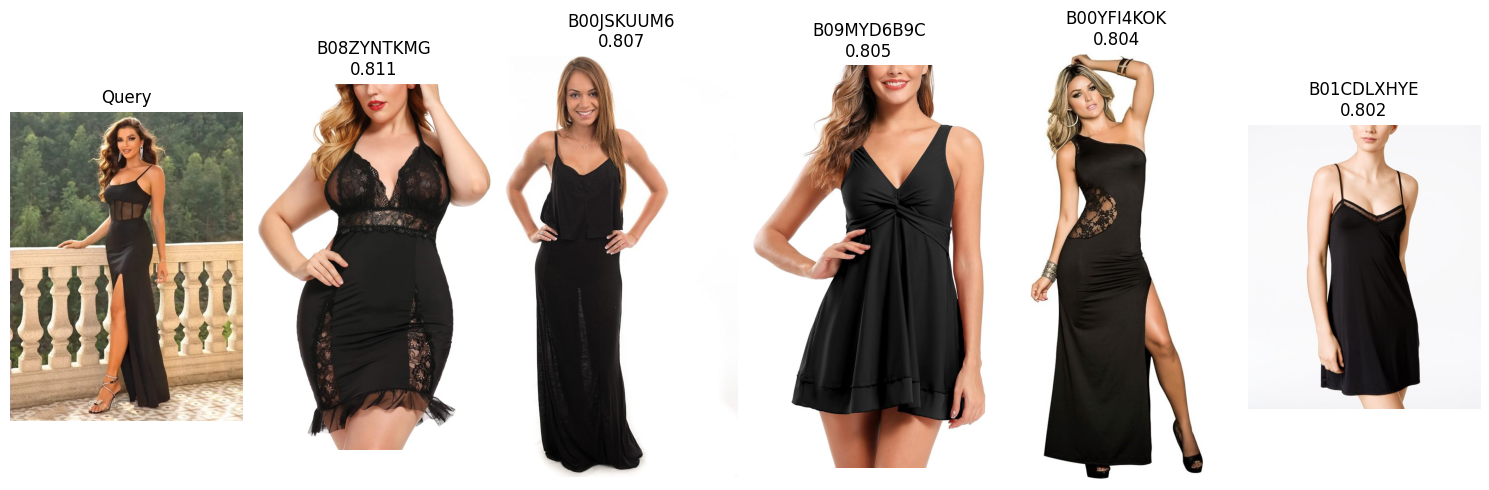

In [ ]:
# To find the recommendation
interactive_search()

# Metrics Evaluation

In [ ]:
import dagshub
# ================= CONFIGURATION =================
dagshub.init(repo_owner='rahulorihiki', repo_name='Fashion_Recommender_with_MLOps_EndtoEnd', mlflow=True)

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=515f37cb-d9d2-466f-a2ea-1ac30c57b149&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=e38ffc07fb847e5f7a953f521155180fd54b67c594daecc55ccf17d8d3c5fa30




Accessing as rahulorihiki

Initialized MLflow to track repo "rahulorihiki/Fashion_Recommender_with_MLOps_EndtoEnd"

Repository rahulorihiki/Fashion_Recommender_with_MLOps_EndtoEnd initialized!

In [ ]:
items = load_dataset("McAuley-Lab/Amazon-Reviews-2023", "raw_meta_Clothing_Shoes_and_Jewelry", split="full", trust_remote_code=True)

In [ ]:
print(items)

In [ ]:
# Earlier considered bought_together for evaluation, but the entire column is empty
# so need to find something different.

import pyarrow.compute as pc

arrow_table = items.data
bought_col = arrow_table.column("bought_together")

# pc.is_valid checks for "Not None"
mask = pc.is_valid(bought_col)

# This avoids processing the full dataset
valid_entries = bought_col.filter(mask).slice(0, 20).to_pylist()

import json
print(f"Found {len(valid_entries)} examples (PyArrow Method):\n")
print(json.dumps(valid_entries, indent=2))

## Data Preparation

### Creating asin_to_images linkage

In [ ]:
# ==========================================
# 1. DEFINE THE TRANSFORMATION LOGIC
# ==========================================
def extract_clean_data(batch):
    """
    Extracts high_res images and parent_asin.
    Returns None for rows that don't have valid data (we filter them later).
    """
    out_parent_asins = []
    out_image_urls = []

    # Iterate over the batch
    for img_data, parent_asin in zip(batch['images'], batch['parent_asin']):

        valid_urls = []
        # Check if data exists
        if img_data and parent_asin:
            hi_res = img_data.get('hi_res', [])
            # Clean the list (remove None values)
            valid_urls = [u for u in hi_res if u is not None]

        # We append WHATEVER we find (empty or not)
        # We will filter out the empty ones in the next step
        out_parent_asins.append(parent_asin)
        out_image_urls.append(valid_urls)

    return {
        "parent_asin": out_parent_asins,
        "image_urls": out_image_urls
    }

# ==========================================
# 2. APPLY MAP (Transformation)
# ==========================================
print("🚀 Mapping and cleaning dataset...")

processed_dataset = items.map(
    extract_clean_data,
    batched=True,
    batch_size=1000,
    num_proc=4, # Multiprocessing enabled
    remove_columns=items.column_names # Drops description, features, etc.
)

# ==========================================
# 3. FILTER (Remove rows with no images)
# ==========================================
print("🧹 Filtering empty rows...")

final_dataset = processed_dataset.filter(
    lambda x: len(x['image_urls']) > 0,
    num_proc=4
)

# ==========================================
# 4. SAVE DIRECTLY (Native Method)
# ==========================================
print(f"💾 Saving {len(final_dataset)} rows to Parquet...")

# Hugging Face handles the chunking/compression internally here
final_dataset.to_parquet("slim_images_metadata.parquet", compression="snappy")

print("✅ DONE. File saved as 'slim_images_metadata.parquet'")

In [ ]:
source_file = "slim_images_metadata.parquet"
dest_folder = "/content/drive/MyDrive/Product_Recommender_End_to_End_with_virtual_dressing/Data/Processed/"
dest_file_path = os.path.join(dest_folder, "asin_to_multi_image_link.parquet")

os.makedirs(dest_folder, exist_ok=True)

# 4. Copy and Rename
if os.path.exists(source_file):
    print(f"🚀 Moving '{source_file}' to Drive...")
    shutil.copy(source_file, dest_file_path)
    print(f"✅ Success! File saved to: {dest_file_path}")
else:
    print(f"❌ Error: Local file '{source_file}' not found. Make sure the extraction step finished.")

### Stratified Sampling

In [ ]:
import duckdb

INPUT_FILE = '/content/drive/MyDrive/Product_Recommender_End_to_End_with_virtual_dressing/Data/Processed/Post_items_cleanup/items_cleaned'
con = duckdb.connect()

df = con.execute(f"select main_categories,count(*) from read_parquet('{INPUT_FILE}') group by main_categories").df()
df

In [ ]:
# ================= CONFIGURATION =================
SAMPLE_SIZE = 50_000
MIN_VARIANTS = 2  # Strict Rule: Must have >= 2 images
FORCE_RESTART = False

BASE_DIR = '/content/drive/MyDrive/Product_Recommender_End_to_End_with_virtual_dressing'
VARIANTS_FILE = f'{BASE_DIR}/Data/Processed/asin_to_multi_image_link.parquet'
ITEMS_FILE = f'{BASE_DIR}/Data/Processed/Post_items_cleanup/items_cleaned'
TEST_DATA_DIR = f'{BASE_DIR}/Data/Processed/Test_data'

# Output Metadata File
META_FILENAME = f'eval_metadata_{SAMPLE_SIZE}_min{MIN_VARIANTS}.parquet'
OUTPUT_FILE = os.path.join(TEST_DATA_DIR, META_FILENAME)
TEMP_CANDIDATES = '/content/temp_candidates.parquet'

os.makedirs(TEST_DATA_DIR, exist_ok=True)

if os.path.exists(OUTPUT_FILE) and FORCE_RESTART == False:
    print(f"✅ Found existing metadata: {OUTPUT_FILE}")
else:
    print(f"🚀 Starting Zero-RAM Sampling...")
    con = duckdb.connect()

    con.execute("PRAGMA threads=8;")
    con.execute("PRAGMA memory_limit='12GB';")

    # 1. JOIN & FILTER (Disk -> Disk)
    # DISTINCT ON ensures 100% Uniqueness even if items_cleaned has duplicates
    print("   ...Filtering candidates...")
    con.execute(f"""
        COPY (
            SELECT DISTINCT ON (v.parent_asin)
                v.parent_asin,
                v.image_urls,
                i.main_categories
            FROM read_parquet('{VARIANTS_FILE}') v
            JOIN read_parquet('{ITEMS_FILE}') i ON v.parent_asin = i.parent_asin
            WHERE len(v.image_urls) >= {MIN_VARIANTS}
        ) TO '{TEMP_CANDIDATES}' (FORMAT PARQUET)
    """)

    # 2. STRATIFIED SAMPLING LOGIC
    print("   ...Calculating category distribution...")
    df_stats = con.execute(f"SELECT main_categories, COUNT(*) as count FROM '{TEMP_CANDIDATES}' GROUP BY main_categories").df()
    total_candidates = df_stats['count'].sum()
    print(f"   ...Total Valid Candidates: {total_candidates:,}")

    if total_candidates <= SAMPLE_SIZE:
        print("   ...Candidates < Target. Keeping all.")
        con.execute(f"COPY (SELECT * FROM '{TEMP_CANDIDATES}') TO '{OUTPUT_FILE}' (FORMAT PARQUET)")
    else:
        # Calculate Quotas
        df_stats['target'] = (df_stats['count'] / total_candidates * SAMPLE_SIZE).round().astype(int)

        # Fix Rounding
        diff = SAMPLE_SIZE - df_stats['target'].sum()
        if diff != 0:
            df_stats.loc[df_stats['count'].idxmax(), 'target'] += diff

        # SQL Case Statement
        case_stmt = "CASE "
        for _, row in df_stats.iterrows():
            cat = row['main_categories'].replace("'", "''")
            case_stmt += f"WHEN main_categories = '{cat}' THEN {row['target']} \n"
        case_stmt += "ELSE 0 END"

        # Execute Sample
        print("   ...Executing Stratified Sample...")
        query = f"""
            COPY (
                WITH Stratified AS (
                    SELECT *,
                        ROW_NUMBER() OVER (PARTITION BY main_categories ORDER BY random()) as rn,
                        ({case_stmt}) as quota
                    FROM '{TEMP_CANDIDATES}'
                )
                SELECT parent_asin, image_urls, main_categories
                FROM Stratified WHERE rn <= quota
            ) TO '{OUTPUT_FILE}' (FORMAT PARQUET)
        """
        con.execute(query)

    con.close()
    if os.path.exists(TEMP_CANDIDATES): os.remove(TEMP_CANDIDATES)
    print(f"✅ Saved Gold Eval Set to: {OUTPUT_FILE}")

In [ ]:
shutil.rmtree('/content/temp_downloads_50000', ignore_errors=True)

### Downloading Stratied images

In [ ]:
# ================= CONFIGURATION =================
SAMPLE_SIZE = 50_000
MIN_VARIANTS = 2
MAX_VARIANTS = 5
MAX_IMAGES_PER_SHARD = 5000

# Concurrency Tuning
OUTER_WORKERS = 4      # Number of Shards processed in parallel
INNER_WORKERS = 7     # Number of Images downloaded in parallel per shard

# Paths
BASE_DIR = '/content/drive/MyDrive/Product_Recommender_End_to_End_with_virtual_dressing'
METADATA_PATH = f'{BASE_DIR}/Data/Processed/Test_data/eval_metadata_{SAMPLE_SIZE}_min{MIN_VARIANTS}.parquet'
DOWNLOAD_ROOT = f'{BASE_DIR}/Data/Processed/Test_data/Eval_Images_{SAMPLE_SIZE}_top{MAX_VARIANTS}_TAR'
LOCAL_ROOT = f'/content/temp_downloads_{SAMPLE_SIZE}'

# Setup
os.makedirs(DOWNLOAD_ROOT, exist_ok=True)
os.makedirs(LOCAL_ROOT, exist_ok=True)

# Sharding Logic
total_estimated_images = SAMPLE_SIZE * MAX_VARIANTS
num_shards = math.ceil(total_estimated_images / MAX_IMAGES_PER_SHARD)

def get_shard_id(parent_asin: str) -> int:
    return int(hashlib.sha256(parent_asin.encode('utf-8')).hexdigest(), 16) % num_shards

HEADERS = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36"
}

def download_one(session: requests.Session, task):
    """Downloads a single image using a shared session (Connection Pooling)."""
    url, save_path = task

    # 1. Resume Check (Skip if exists)
    if os.path.exists(save_path):
        try:
            if os.path.getsize(save_path) > 200:
                return 1
        except: pass

    try:
        # 2. Network Request
        r = session.get(url, stream=True, timeout=8)
        if r.status_code != 200: return 0

        # 3. Content Type Check
        ctype = r.headers.get("Content-Type", "")
        if "image" not in ctype: return 0

        # 4. Stream to Disk (Fastest Method)
        with open(save_path, "wb") as f:
            for chunk in r.iter_content(chunk_size=65536): # 64KB chunks
                if chunk: f.write(chunk)

        return 1
    except:
        return 0

def process_shard(shard_data):
    """Manager function for a single shard."""
    shard_id, rows = shard_data

    # 1. ATOMIC RESUME LOGIC (The Fix)
    tar_name = f"Shard_{shard_id}.tar"
    drive_tar_path = os.path.join(DOWNLOAD_ROOT, tar_name)
    drive_tmp_path = os.path.join(DOWNLOAD_ROOT, tar_name + ".tmp")

    # If the .tar exists, we KNOW it is complete because of our atomic rename logic
    if os.path.exists(drive_tar_path) and os.path.getsize(drive_tar_path) > 1024:
        return (0, 0)

    # 2. Setup Local Folder
    local_shard_dir = os.path.join(LOCAL_ROOT, f"Shard_{shard_id}")
    os.makedirs(local_shard_dir, exist_ok=True)

    # 3. Prepare Tasks
    tasks = []
    for row in rows:
        p_asin = row.get("parent_asin")
        raw_urls = row.get("image_urls")

        urls = None
        if isinstance(raw_urls, np.ndarray): urls = raw_urls.tolist()
        elif isinstance(raw_urls, list): urls = raw_urls
        elif isinstance(raw_urls, str):
            try: urls = ast.literal_eval(raw_urls)
            except: pass

        if not urls: continue

        for i, url in enumerate(urls[:MAX_VARIANTS]):
            filename = f"{p_asin}_{i}.jpg"
            save_path = os.path.join(local_shard_dir, filename)
            tasks.append((url, save_path))

    count_expected = len(tasks)
    if count_expected == 0:
        shutil.rmtree(local_shard_dir, ignore_errors=True)
        return (0, 0)

    # 4. Download Loop (Inner Parallelism)
    session = requests.Session()
    session.headers.update(HEADERS)

    # ⚡ FIX: Increase Pool Size to match INNER_WORKERS (stop warnings)
    adapter = requests.adapters.HTTPAdapter(
        pool_connections=INNER_WORKERS,
        pool_maxsize=INNER_WORKERS,
        max_retries=2
    )
    session.mount('https://', adapter)
    session.mount('http://', adapter)

    count_success = 0
    with ThreadPoolExecutor(max_workers=INNER_WORKERS) as ex:
        results = ex.map(lambda t: download_one(session, t), tasks)
        count_success = sum(results)

    # 5. Tar It (Uncompressed)
    local_tar_path = os.path.join(LOCAL_ROOT, tar_name)
    with tarfile.open(local_tar_path, "w") as tar:
        tar.add(local_shard_dir, arcname=f"Shard_{shard_id}")

    # 6. ATOMIC SHIP (Copy to .tmp -> Rename to .tar)
    try:
        shutil.copy2(local_tar_path, drive_tmp_path) # Upload as .tmp
        os.rename(drive_tmp_path, drive_tar_path)    # Rename ONLY when done
    except Exception as e:
        print(f"⚠️ Upload failed for Shard {shard_id}: {e}")
        # If upload fails, we don't rename, so next run knows to retry

    # 7. Cleanup
    shutil.rmtree(local_shard_dir, ignore_errors=True)
    try: os.remove(local_tar_path)
    except: pass

    return (count_success, count_expected)

# ================= EXECUTION WITH SAFETY =================
if __name__ == "__main__":
    try:
        print(f"🚀 Downloading {num_shards} shards to: {DOWNLOAD_ROOT}")
        df = pd.read_parquet(METADATA_PATH)

        # Grouping
        shard_groups = {i: [] for i in range(num_shards)}
        for row in tqdm(df.to_dict('records'), desc="Grouping"):
            shard_groups[get_shard_id(row["parent_asin"])].append(row)

        del df; gc.collect()

        inputs = [(sid, rows) for sid, rows in shard_groups.items() if rows]

        print(f"⚡ Turbo Mode: {OUTER_WORKERS} Shards x {INNER_WORKERS} Threads")

        with ThreadPoolExecutor(max_workers=OUTER_WORKERS) as ex:
            results = list(tqdm(ex.map(process_shard, inputs), total=len(inputs), desc="Processing Shards"))

        # Report
        total_success = sum(s for s, _ in results)
        total_expected = sum(e for _, e in results)

        print("\n📊 --- REPORT ---")
        print(f"✅ Success: {total_success:,} / {total_expected:,}")
        if total_expected:
            print(f"📉 Success Rate: {(total_success/total_expected*100):.2f}%")

    except KeyboardInterrupt:
        print("\n🛑 Execution Interrupted by User!")

    finally:
        # 8. GLOBAL CLEANUP (Runs even if you press Stop)
        print("🧹 Cleaning up local temporary files...")
        if os.path.exists(LOCAL_ROOT):
            shutil.rmtree(LOCAL_ROOT, ignore_errors=True)
        print("✅ Cleanup Complete.")

In [ ]:
print("⏳ Flushing buffer to cloud...")
drive.flush_and_unmount()
print("✅ Done. Re-mounting...")
drive.mount('/content/drive')

### Verification

In [ ]:
# Must match your Downloader config
SAMPLE_SIZE = 50_000
MIN_VARIANTS = 2
MAX_VARIANTS = 5

BASE_DIR = '/content/drive/MyDrive/Product_Recommender_End_to_End_with_virtual_dressing'
# ⚡ UPDATE: Pointing to the TAR directory
DOWNLOAD_ROOT = f'{BASE_DIR}/Data/Processed/Test_data/Eval_Images_{SAMPLE_SIZE}_top{MAX_VARIANTS}_TAR'

print(f"📂 Scanning Root: {DOWNLOAD_ROOT}")

if not os.path.exists(DOWNLOAD_ROOT):
    print("❌ Error: Download root folder does not exist.")
else:
    total_images = 0
    valid_shards = 0
    corrupt_shards = []

    # Get all .tar files
    tar_files = sorted([f for f in os.listdir(DOWNLOAD_ROOT) if f.endswith('.tar')])

    if not tar_files:
        print("⚠️ No .tar files found! Did the download finish?")
    else:
        print(f"🔍 Found {len(tar_files)} tar files. Verifying integrity...")
        print("-" * 50)

        for tar_name in tqdm(tar_files, desc="Checking Shards"):
            file_path = os.path.join(DOWNLOAD_ROOT, tar_name)

            try:
                # 1. Check File Size (Basic Check)
                size_mb = os.path.getsize(file_path) / (1024 * 1024)
                if size_mb < 1:
                    print(f"   ❌ {tar_name}: File too small ({size_mb:.2f} MB). Likely corrupt.")
                    corrupt_shards.append(tar_name)
                    continue

                # 2. Peek Inside (Deep Check)
                # We open in 'r' mode to read the header. This validates the Tar structure.
                with tarfile.open(file_path, 'r') as tar:
                    # getnames() is fast; it just reads the header list, doesn't extract data
                    member_names = tar.getnames()
                    # Filter for actual images (ignore folders/hidden files)
                    image_count = len([m for m in member_names if m.endswith('.jpg') or m.endswith('.jpeg')])

                print(f"   ✅ {tar_name}: {image_count:,} images ({size_mb:.1f} MB)")
                total_images += image_count
                valid_shards += 1

            except Exception as e:
                print(f"   ❌ {tar_name}: CORRUPT HEADER! Error: {str(e)}")
                corrupt_shards.append(tar_name)

        print("-" * 50)
        print("📊 --- FINAL DIAGNOSTICS ---")
        print(f"✅ Valid Shards:   {valid_shards}")
        print(f"📸 Total Images:   {total_images:,}")

        if corrupt_shards:
            print(f"❌ Corrupt Files:  {len(corrupt_shards)}")
            print("⚠️ ACTION REQUIRED: Delete these files and re-run the downloader:")
            for c in corrupt_shards:
                print(f"   rm {os.path.join(DOWNLOAD_ROOT, c)}")
        else:
            print("🚀 STATUS: HEALTHY. Dataset is ready for Embedding.")

📂 Scanning Root: /content/drive/MyDrive/Product_Recommender_End_to_End_with_virtual_dressing/Data/Processed/Test_data/Eval_Images_50000_top5_TAR
🔍 Found 50 tar files. Verifying integrity...
--------------------------------------------------


Checking Shards:   0%|          | 0/50 [00:00<?, ?it/s]

   ✅ Shard_0.tar: 4,273 images (443.3 MB)
   ✅ Shard_1.tar: 4,183 images (433.4 MB)
   ✅ Shard_10.tar: 4,375 images (457.4 MB)
   ✅ Shard_11.tar: 4,194 images (438.6 MB)
   ✅ Shard_12.tar: 4,342 images (455.8 MB)
   ✅ Shard_13.tar: 4,198 images (447.0 MB)
   ✅ Shard_14.tar: 4,362 images (450.6 MB)
   ✅ Shard_15.tar: 4,163 images (434.5 MB)
   ✅ Shard_16.tar: 4,168 images (439.5 MB)
   ✅ Shard_17.tar: 4,232 images (444.8 MB)
   ✅ Shard_18.tar: 4,021 images (415.6 MB)
   ✅ Shard_19.tar: 4,373 images (459.5 MB)
   ✅ Shard_2.tar: 4,031 images (413.4 MB)
   ✅ Shard_20.tar: 4,175 images (442.7 MB)
   ✅ Shard_21.tar: 4,122 images (428.0 MB)
   ✅ Shard_22.tar: 3,960 images (410.8 MB)
   ✅ Shard_23.tar: 4,571 images (481.0 MB)
   ✅ Shard_24.tar: 4,331 images (453.2 MB)
   ✅ Shard_25.tar: 4,213 images (442.5 MB)
   ✅ Shard_26.tar: 4,430 images (462.4 MB)
   ✅ Shard_27.tar: 4,340 images (441.9 MB)
   ✅ Shard_28.tar: 4,219 images (454.1 MB)
   ✅ Shard_29.tar: 3,972 images (421.8 MB)
   ✅ Shard_3.t

## Variant Metric Testing

In [ ]:
# ================= CONFIGURATION =================
# 1. NEW: Add Model Name to switch dynamically
MODEL_NAME = "convnext"

SAMPLE_SIZE = 10_000
MIN_VARIANTS = 2
MAX_VARIANTS = 5
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

BASE_DIR = '/content/drive/MyDrive/Product_Recommender_End_to_End_with_virtual_dressing'
TEST_DATA_DIR = f'{BASE_DIR}/Data/Processed/Test_data'
METADATA_PATH = f'{TEST_DATA_DIR}/eval_metadata_{SAMPLE_SIZE}_min{MIN_VARIANTS}.parquet'

# 2. NEW: Inject MODEL_NAME into the save file so different models don't overwrite each other
EMBEDDING_FILE = f'{TEST_DATA_DIR}/embeddings_{MODEL_NAME}_{SAMPLE_SIZE}_top{MAX_VARIANTS}_sharded.pt'

TAR_SOURCE_ROOT = f'{TEST_DATA_DIR}/Eval_Images_{SAMPLE_SIZE}_top{MAX_VARIANTS}_TAR'
LOCAL_TEMP_ROOT = f'/content/temp_shard_workspace'

MAX_IMAGES_PER_SHARD = 5000
total_estimated_images = SAMPLE_SIZE * MAX_VARIANTS
num_shards = math.ceil(total_estimated_images / MAX_IMAGES_PER_SHARD)

def get_shard_id(parent_asin: str) -> int:
    return int(hashlib.sha256(parent_asin.encode('utf-8')).hexdigest(), 16) % num_shards

# ================= DATASET =================
class SingleShardDataset(Dataset):
    """
    Uses a precomputed mapping of parent_asin -> list of (variant_idx, full_path),
    built using a one-time directory listing (fast).
    """
    def __init__(self, shard_folder, rows, tfm, max_variants):
        self.transform = tfm
        self.samples = []  # (parent_asin, variant_idx, full_path)

        # Build a fast in-RAM set of filenames once
        try:
            files_in_dir = set(os.listdir(shard_folder))
        except FileNotFoundError:
            files_in_dir = set()

        for row in rows:
            p_asin = row.get('parent_asin')
            if not p_asin:
                continue

            found = []
            for i in range(max_variants):
                fname = f"{p_asin}_{i}.jpg"
                if fname in files_in_dir:
                    found.append((i, os.path.join(shard_folder, fname)))

            if len(found) >= 2:
                for i, pth in found:
                    self.samples.append((p_asin, i, pth))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        p, i, path = self.samples[idx]
        try:
            img = Image.open(path).convert('RGB')
            return p, i, self.transform(img)
        except:
            return p, i, torch.zeros(3, 224, 224)

# ================= EXECUTION =================
if os.path.exists(EMBEDDING_FILE):
    print(f"✅ Embeddings already exist: {EMBEDDING_FILE}")
else:
    print(f"🧠 Generating Embeddings for {MODEL_NAME.upper()} on {DEVICE}...")

    os.makedirs(LOCAL_TEMP_ROOT, exist_ok=True)

    # 3. NEW: Replaced ResNet with ModelFactory
    wrapper_instance = ModelFactory.get_model(MODEL_NAME, device=DEVICE)
    tfm = wrapper_instance.get_transforms()

    # 4. NEW: Dynamic Dimension Detection
    dummy = torch.zeros(1, 3, 224, 224).to(DEVICE)
    with torch.no_grad():
        GLOBAL_DIM = wrapper_instance.embed_image(dummy).shape[1]
    print(f"📐 Auto-Detected Embedding Dimension: {GLOBAL_DIM}")

    # Metadata -> shard_map
    print("📂 Loading Metadata...")
    df_meta = pd.read_parquet(METADATA_PATH)
    shard_map = {i: [] for i in range(num_shards)}
    for row in tqdm(df_meta.to_dict('records'), desc="Grouping Metadata"):
        sid = get_shard_id(row['parent_asin'])
        shard_map[sid].append(row)
    del df_meta
    gc.collect()

    final_embeddings = {}  # parent_asin -> (MAX_VARIANTS, dim) + mask

    print(f"🚀 Processing {num_shards} shards...")

    for shard_id in range(num_shards):
        rows = shard_map[shard_id]
        if not rows:
            continue

        tar_name = f"Shard_{shard_id}.tar"
        tar_path = os.path.join(TAR_SOURCE_ROOT, tar_name)
        if not os.path.exists(tar_path):
            continue

        print(f"\n🔹 Processing {tar_name} ...")

        # Extract: tar contains a top folder "Shard_{id}"
        shard_root = os.path.join(LOCAL_TEMP_ROOT, f"Shard_{shard_id}")
        shutil.rmtree(shard_root, ignore_errors=True)
        os.makedirs(shard_root, exist_ok=True)

        try:
            with tarfile.open(tar_path, 'r') as tar:
                tar.extractall(path=shard_root, filter='data')

            # Actual image folder after extract:
            shard_folder = os.path.join(shard_root, f"Shard_{shard_id}")
            if not os.path.exists(shard_folder):
                # fallback: sometimes tars are flat
                shard_folder = shard_root

            ds = SingleShardDataset(shard_folder, rows, tfm, MAX_VARIANTS)
            if len(ds) == 0:
                print("   ⚠️ No usable multi-view items in this shard.")
                continue

            dl = DataLoader(
                ds,
                batch_size=256,
                num_workers=4,
                pin_memory=True,
                prefetch_factor=2,
                persistent_workers=True
            )

            shard_storage = {}   # parent -> (arr, mask)

            if DEVICE == "cuda":
                torch.cuda.empty_cache()

            with torch.inference_mode():
                for p_asins, idxs, imgs in tqdm(dl, desc="   Embedding", leave=False):

                    # 5. NEW: Replaced ResNet forward pass with wrapper.embed_image()
                    if DEVICE == "cuda":
                        imgs = imgs.to(DEVICE, non_blocking=True).to(memory_format=torch.channels_last)
                        with torch.amp.autocast('cuda'):
                            embs_tensor = wrapper_instance.embed_image(imgs)
                    else:
                        imgs = imgs.to(DEVICE)
                        embs_tensor = wrapper_instance.embed_image(imgs)

                    # Note: wrapper already normalizes. Just move to CPU/Numpy.
                    embs = embs_tensor.float().cpu().numpy()

                    for k, p in enumerate(p_asins):
                        idx_val = int(idxs[k].item())
                        if p not in shard_storage:
                            shard_storage[p] = (
                                np.zeros((MAX_VARIANTS, GLOBAL_DIM), dtype=np.float32), # Uses dynamic dim
                                np.zeros((MAX_VARIANTS,), dtype=np.bool_)
                            )
                        arr, m = shard_storage[p]
                        arr[idx_val] = embs[k]
                        m[idx_val] = True

            # Merge
            parents = 0
            total_images = 0
            for p, (arr, m) in shard_storage.items():
                if m.sum() >= 2:
                    final_embeddings[p] = (arr, m)
                    parents += 1
                    total_images += m.sum()
            print(f"   ✅ Added {parents} products ({total_images} images) from this shard.")

            del dl, ds, shard_storage
            gc.collect()

        except Exception as e:
            print(f"   ❌ Error processing shard: {e}")

        finally:
            # Delete only this shard extraction
            shutil.rmtree(shard_root, ignore_errors=True)
            gc.collect()

    print("-" * 30)
    print("💾 Saving consolidated embeddings...")
    torch.save(final_embeddings, EMBEDDING_FILE)
    print(f"✅ Saved {len(final_embeddings)} items to {EMBEDDING_FILE}")
    print("🎉 JOB DONE!")

🧠 Generating Embeddings for CONVNEXT on cuda...
Loading ConvNeXt-base on cuda...
📐 Auto-Detected Embedding Dimension: 1024
📂 Loading Metadata...


Grouping Metadata:   0%|          | 0/10000 [00:00<?, ?it/s]

🚀 Processing 10 shards...

🔹 Processing Shard_0.tar ...


   Embedding:   0%|          | 0/17 [00:00<?, ?it/s]

   ✅ Added 994 products (4162 images) from this shard.

🔹 Processing Shard_1.tar ...


...

   ✅ Added 972 products (4071 images) from this shard.

🔹 Processing Shard_8.tar ...


   Embedding:   0%|          | 0/17 [00:00<?, ?it/s]

   ✅ Added 978 products (4147 images) from this shard.

🔹 Processing Shard_9.tar ...


   Embedding:   0%|          | 0/18 [00:00<?, ?it/s]

   ✅ Added 1062 products (4528 images) from this shard.
------------------------------
💾 Saving consolidated embeddings...
✅ Saved 10000 items to /content/drive/MyDrive/Product_Recommender_End_to_End_with_virtual_dressing/Data/Processed/Test_data/embeddings_convnext_10000_top5_sharded.pt
🎉 JOB DONE!


In [ ]:
import os
import torch
import numpy as np
import faiss
import mlflow
from tqdm.auto import tqdm

# ================= CONFIGURATION =================
EXPERIMENT_NAME = "Content_Based_Retrieval"

# 1. NEW: Set this to match the model you just embedded
MODEL_NAME = "convnext"

SAMPLE_SIZE = 10_000
MIN_VARIANTS = 2
MAX_VARIANTS = 5
BOOTSTRAP_ROUNDS = 50
SUB_SAMPLE_SIZE = 2000
K_METRIC = 10
QUERY_BATCH_SIZE = 1024

USE_GPU = torch.cuda.is_available()

# Paths
BASE_DIR = '/content/drive/MyDrive/Product_Recommender_End_to_End_with_virtual_dressing'
TEST_DATA_DIR = f'{BASE_DIR}/Data/Processed/Test_data'

# 2. NEW: Updated to match the dynamic filename we created in the embedding script
EMBEDDING_FILE = f'{TEST_DATA_DIR}/embeddings_{MODEL_NAME}_{SAMPLE_SIZE}_top{MAX_VARIANTS}_sharded.pt'

# ================= START MLFLOW RUN =================
mlflow.set_experiment(EXPERIMENT_NAME)

with mlflow.start_run(run_name=f"{MODEL_NAME}_Top{MAX_VARIANTS}_Eval"):

    # 1. LOG PARAMETERS
    mlflow.log_params({
        "model_architecture": MODEL_NAME,
        "sample_size": SAMPLE_SIZE,
        "max_variants": MAX_VARIANTS,
        "bootstrap_rounds": BOOTSTRAP_ROUNDS,
        "k_metric": K_METRIC
    })

    # ================= 2. LOAD & CLEAN EMBEDDINGS =================
    if not os.path.exists(EMBEDDING_FILE):
        raise FileNotFoundError(f"❌ Embeddings not found at {EMBEDDING_FILE}")

    print(f"📂 Loading Embeddings for {MODEL_NAME.upper()} from Drive...")
    # Load raw data (dictionary of tuples)
    raw_data = torch.load(EMBEDDING_FILE, map_location='cpu', weights_only=False)

    print(f"🧹 Pre-processing: Unpacking masks and filtering valid vectors...")
    all_embeddings = {}

    # ⚡ Handle the (arr, mask) format ⚡
    for p_asin, (full_arr, mask) in raw_data.items():
        # Apply the boolean mask to get only the valid (downloaded) images
        valid_vecs = full_arr[mask]

        # We need at least 2 images (1 Query + 1 Target) to evaluate retrieval
        if valid_vecs.shape[0] >= 2:
            all_embeddings[p_asin] = valid_vecs

    print(f"✅ Loaded and Cleaned {len(all_embeddings)} items.")

    # ================= 3. BUILD GLOBAL INDEX =================
    print(f"🏗️ Building Global Index...")
    valid_parents = list(all_embeddings.keys())

    # Precompute siblings count (Total variants - 1 query)
    # This is the DENOMINATOR for True Recall
    parent_to_siblings = {p: all_embeddings[p].shape[0]-1 for p in valid_parents}

    all_vectors = []
    all_parent_ids = []

    for p_idx, p_asin in enumerate(valid_parents):
        embs = all_embeddings[p_asin]
        for v in embs:
            all_vectors.append(v)
            all_parent_ids.append(p_idx)

    all_vectors = np.vstack(all_vectors).astype('float32')
    all_parent_ids = np.array(all_parent_ids)

    # Standard CPU Index (Fast enough for 42k vectors)
    index = faiss.IndexFlatIP(all_vectors.shape[1])

    if USE_GPU:
        print("⚡ Moving FAISS Index to GPU...")
        res = faiss.StandardGpuResources()
        index = faiss.index_cpu_to_gpu(res, 0, index)

    index.add(all_vectors)
    print(f"✅ FAISS Index Ready: {len(all_vectors)} vectors.")

    # ================= 4. METRIC FUNCTION =================
    def compute_metrics(batch_vecs, batch_true_parents, K=K_METRIC):
        # 1. Search
        D, I = index.search(batch_vecs, K + 1)

        # 2. Exclude Self (Rank 0)
        retrieved_indices = I[:, 1:]
        retrieved_parents = all_parent_ids[retrieved_indices]

        # 3. Hits Matrix (Batch x K)
        true_parents = batch_true_parents[:, None]
        hits = (retrieved_parents == true_parents).astype(float)

        # --- Metric 1: Hit Rate (Formerly Recall) ---
        # Did we find AT LEAST ONE relevant item?
        hit_rate_batch = hits.any(axis=1).astype(float)

        # --- Metric 2: True Recall ---
        # (Total Hits Found) / (Total Existing Siblings)
        num_siblings = np.array([parent_to_siblings[valid_parents[p]] for p in batch_true_parents])

        # Sum hits across K for each query
        total_hits = hits.sum(axis=1)

        # Avoid division by zero (though filtering >=2 ensures num_siblings >=1)
        true_recall_batch = np.divide(total_hits, num_siblings, out=np.zeros_like(total_hits), where=num_siblings > 0)

        # --- Metric 3: NDCG ---
        discounts = 1.0 / np.log2(np.arange(K) + 2)
        dcg = (hits * discounts).sum(axis=1)

        max_possible_hits = np.minimum(num_siblings, K).astype(int)

        ideal_discounts = 1.0 / np.log2(np.arange(2, K + 2))
        idcg_cumsum = np.cumsum(ideal_discounts)
        idcg = np.where(max_possible_hits > 0, idcg_cumsum[max_possible_hits - 1], 1.0)

        ndcg_batch = np.divide(dcg, idcg, out=np.zeros_like(dcg), where=idcg > 0)

        # --- Metric 4: MRR ---
        first_hit_indices = hits.argmax(axis=1)
        mrr_batch = np.where(
            hit_rate_batch > 0,
            1.0 / (first_hit_indices + 1),
            0.0
        )

        return hit_rate_batch, true_recall_batch, ndcg_batch, mrr_batch

    # ================= 5. BOOTSTRAP LOOP =================
    # Added storage for True Recall and Hit Rate
    results = {
        'HitRate_at_10': [],
        'True_Recall_at_10': [],
        'NDCG_at_10': [],
        'MRR_at_10': []
    }

    print(f"🚀 Starting {BOOTSTRAP_ROUNDS} Rounds...")
    for _ in tqdm(range(BOOTSTRAP_ROUNDS), desc="Bootstrapping"):
        sample_parent_indices = np.random.choice(len(valid_parents), size=SUB_SAMPLE_SIZE, replace=True)

        query_vecs = []
        query_parents = []

        for p_idx in sample_parent_indices:
            embs = all_embeddings[valid_parents[p_idx]]
            if embs.shape[0] >= 2:
                q_idx = np.random.randint(0, embs.shape[0])
                query_vecs.append(embs[q_idx])
                query_parents.append(p_idx)

        query_vecs = np.vstack(query_vecs).astype('float32')
        query_parents = np.array(query_parents)

        # Batched Scoring
        hit_rate_list = []
        true_recall_list = []
        ndcg_list = []
        mrr_list = []

        for start in range(0, len(query_vecs), QUERY_BATCH_SIZE):
            end = min(start + QUERY_BATCH_SIZE, len(query_vecs))
            batch_vecs = query_vecs[start:end]
            batch_parents = query_parents[start:end]

            # Unpack 4 return values now
            hr_batch, tr_batch, n_batch, m_batch = compute_metrics(batch_vecs, batch_parents, K=K_METRIC)

            hit_rate_list.append(hr_batch)
            true_recall_list.append(tr_batch)
            ndcg_list.append(n_batch)
            mrr_list.append(m_batch)

        results['HitRate_at_10'].append(np.concatenate(hit_rate_list).mean())
        results['True_Recall_at_10'].append(np.concatenate(true_recall_list).mean())
        results['NDCG_at_10'].append(np.concatenate(ndcg_list).mean())
        results['MRR_at_10'].append(np.concatenate(mrr_list).mean())

    # ================= 6. LOGGING =================
    mean_hitrate = np.mean(results['HitRate_at_10'])
    std_hitrate = np.std(results['HitRate_at_10'])

    mean_true_recall = np.mean(results['True_Recall_at_10'])
    std_true_recall = np.std(results['True_Recall_at_10'])

    mean_ndcg = np.mean(results['NDCG_at_10'])
    std_ndcg = np.std(results['NDCG_at_10'])

    mean_mrr = np.mean(results['MRR_at_10'])
    std_mrr = np.std(results['MRR_at_10'])

    print("\n🏆 --- FINAL RESULTS ---")
    print(f"HitRate_at_10:     {mean_hitrate*100:.2f}% ± {std_hitrate*100:.2f}")
    print(f"True_Recall_at_10: {mean_true_recall*100:.2f}% ± {std_true_recall*100:.2f}")
    print(f"NDCG_at_10:        {mean_ndcg:.4f} ± {std_ndcg:.4f}")
    print(f"MRR_at_10:         {mean_mrr:.4f} ± {std_mrr:.4f}")

    mlflow.log_metrics({
      "HitRate_at_10_Mean":    float(mean_hitrate),
      "HitRate_at_10_Std":     float(std_hitrate),
      "True_Recall_at_10_Mean": float(mean_true_recall),
      "True_Recall_at_10_Std":  float(std_true_recall),
      "NDCG_at_10_Mean":       float(mean_ndcg),
      "NDCG_at_10_Std":        float(std_ndcg),
      "MRR_at_10_Mean":        float(mean_mrr),
      "MRR_at_10_Std":         float(std_mrr)
    })

    print("✅ Metrics logged to Dagshub/MLflow!")

📂 Loading Embeddings for CONVNEXT from Drive...
🧹 Pre-processing: Unpacking masks and filtering valid vectors...
✅ Loaded and Cleaned 10000 items.
🏗️ Building Global Index...
⚡ Moving FAISS Index to GPU...
✅ FAISS Index Ready: 42177 vectors.
🚀 Starting 50 Rounds...


Bootstrapping:   0%|          | 0/50 [00:00<?, ?it/s]


🏆 --- FINAL RESULTS ---
HitRate_at_10:     38.45% ± 1.04
True_Recall_at_10: 21.47% ± 0.75
NDCG_at_10:        0.2133 ± 0.0074
MRR_at_10:         0.3029 ± 0.0098
✅ Metrics logged to Dagshub/MLflow!
🏃 View run convnext_Top5_Eval at: https://dagshub.com/rahulorihiki/Fashion_Recommender_with_MLOps_EndtoEnd.mlflow/#/experiments/0/runs/66ac3c9c12874749ae048ea8ea61e9cd
🧪 View experiment at: https://dagshub.com/rahulorihiki/Fashion_Recommender_with_MLOps_EndtoEnd.mlflow/#/experiments/0


## Augmented Metric Testing

In [ ]:
# ================= CONFIGURATION =================
# 1. NEW: Add Model Name to switch dynamically
MODEL_NAME = "convnext"

SAMPLE_SIZE = 10_000
MIN_VARIANTS = 2
MAX_VARIANTS = 5       # Max variants available in the TARs
NUM_AUGMENTS = 5       # 1 Clean + 5 Augments = 6 images per item
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Paths
BASE_DIR = '/content/drive/MyDrive/Product_Recommender_End_to_End_with_virtual_dressing'
TEST_DATA_DIR = f'{BASE_DIR}/Data/Processed/Test_data'
METADATA_PATH = f'{TEST_DATA_DIR}/eval_metadata_{SAMPLE_SIZE}_min{MIN_VARIANTS}.parquet'

# 2. NEW: Inject MODEL_NAME into the save file so different models don't overwrite
EMBEDDING_FILE = f'{TEST_DATA_DIR}/embeddings_{MODEL_NAME}_augmented_{SAMPLE_SIZE}_{NUM_AUGMENTS}x.pt'

# Input Tars (Drive)
TAR_SOURCE_ROOT = f'{TEST_DATA_DIR}/Eval_Images_{SAMPLE_SIZE}_top{MAX_VARIANTS}_TAR'
# Temp Workspace (Local SSD)
LOCAL_TEMP_ROOT = f'/content/temp_aug_workspace'

# Sharding Logic
MAX_IMAGES_PER_SHARD = 5000
total_estimated_images = SAMPLE_SIZE * MAX_VARIANTS
num_shards = math.ceil(total_estimated_images / MAX_IMAGES_PER_SHARD)

def get_shard_id(p_asin):
    return int(hashlib.sha256(p_asin.encode('utf-8')).hexdigest(), 16) % num_shards

# ================= 1. TRANSFORMS & MODEL =================
# 3. NEW: Load Model via Factory
wrapper_instance = ModelFactory.get_model(MODEL_NAME, device=DEVICE)

# A. Target (Clean) - Uses the dynamic factory transform
clean_transform = wrapper_instance.get_transforms()

# B. Queries (Noisy/Augmented) - Applies your exact augmentations, then factory normalization
pil_augment = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.6, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.GaussianBlur(kernel_size=3)
])

def augment_transform(img):
    """Applies your visual augmentations, then formats the tensor for the specific model."""
    return clean_transform(pil_augment(img))

# ================= 2. DATASET =================
class SingleShardAugDataset(Dataset):
    """
    Loads Index 0 (Main Image) from the extracted shard folder and generates augmentations.
    """
    def __init__(self, shard_folder, rows, num_augs):
        self.samples = []
        self.num_augs = num_augs

        # Build fast lookup set
        try:
            files_in_dir = set(os.listdir(shard_folder))
        except FileNotFoundError:
            files_in_dir = set()

        for row in rows:
            p_asin = row.get('parent_asin')

            # We ONLY want the main image (Index 0) for robustness testing
            filename = f"{p_asin}_0.jpg"

            if filename in files_in_dir:
                full_path = os.path.join(shard_folder, filename)
                self.samples.append((p_asin, full_path))

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        p_asin, path = self.samples[idx]
        try:
            img = Image.open(path).convert('RGB')

            # Stack: [Clean, Aug1, Aug2, ... AugN]
            tensors = [clean_transform(img)]
            for _ in range(self.num_augs):
                tensors.append(augment_transform(img))

            # Returns shape: (N+1, 3, 224, 224)
            return p_asin, torch.stack(tensors)
        except:
            # Fallback for corrupt images
            return p_asin, torch.zeros(self.num_augs + 1, 3, 224, 224)

# ================= 3. EXECUTION =================
if os.path.exists(EMBEDDING_FILE):
    print(f"✅ Embeddings already exist: {EMBEDDING_FILE}")
else:
    print(f"🧠 Generating Robustness Embeddings for {MODEL_NAME.upper()} on {DEVICE}...")

    # 4. NEW: Dynamic Dimension Detection (for logging)
    dummy = torch.zeros(1, 3, 224, 224).to(DEVICE)
    with torch.no_grad():
        GLOBAL_DIM = wrapper_instance.embed_image(dummy).shape[1]
    print(f"📐 Auto-Detected Embedding Dimension: {GLOBAL_DIM}")

    # Metadata
    print("📂 Loading Metadata...")
    df_meta = pd.read_parquet(METADATA_PATH)

    shard_map = {i: [] for i in range(num_shards)}
    for row in tqdm(df_meta.to_dict('records'), desc="Grouping Metadata"):
        sid = get_shard_id(row['parent_asin'])
        shard_map[sid].append(row)
    del df_meta; gc.collect()

    final_results = {} # Dict[p_asin] = np.array shape (6, dynamic_dim)

    print(f"🚀 Starting Stream Processing for {num_shards} Shards...")
    os.makedirs(LOCAL_TEMP_ROOT, exist_ok=True)

    for shard_id in range(num_shards):
        tar_name = f"Shard_{shard_id}.tar"
        tar_path = os.path.join(TAR_SOURCE_ROOT, tar_name)

        if not os.path.exists(tar_path) or not shard_map[shard_id]:
            continue

        print(f"\n🔹 Processing {tar_name}...")

        # A. EXTRACT
        shard_root = os.path.join(LOCAL_TEMP_ROOT, f"Shard_{shard_id}")
        shutil.rmtree(shard_root, ignore_errors=True)
        os.makedirs(shard_root, exist_ok=True)

        try:
            with tarfile.open(tar_path, 'r') as tar:
                tar.extractall(path=shard_root, filter='data')

            # Handle potentially nested folders
            shard_folder = os.path.join(shard_root, f"Shard_{shard_id}")
            if not os.path.exists(shard_folder):
                shard_folder = shard_root

            # B. DATASET
            ds = SingleShardAugDataset(shard_folder, shard_map[shard_id], NUM_AUGMENTS)

            if len(ds) == 0:
                print("   ⚠️ No valid anchor images found.")
                continue

            dl = DataLoader(
                ds,
                batch_size=32,   # Batch 32 * 6 images = 192 total
                num_workers=4,
                pin_memory=True,
                prefetch_factor=2,
                persistent_workers=True
            )

            # C. INFERENCE
            if DEVICE == "cuda": torch.cuda.empty_cache()

            with torch.inference_mode():
                for p_asins, stacks in tqdm(dl, desc="   Augmenting", leave=False):
                    # stacks shape: [Batch, 6, 3, 224, 224]
                    B, N, C, H, W = stacks.shape

                    # Flatten -> [Batch*6, 3, 224, 224]
                    flat_imgs = stacks.view(-1, C, H, W)

                    # 5. NEW: Replaced ResNet forward pass with ModelFactory
                    if DEVICE == "cuda":
                        flat_imgs = flat_imgs.to(DEVICE, non_blocking=True).to(memory_format=torch.channels_last)
                        with torch.amp.autocast('cuda'):
                            embs_tensor = wrapper_instance.embed_image(flat_imgs)
                    else:
                        flat_imgs = flat_imgs.to(DEVICE)
                        embs_tensor = wrapper_instance.embed_image(flat_imgs)

                    # Note: wrapper already normalizes. Just move to CPU/Numpy.
                    embs = embs_tensor.float().cpu().numpy()

                    # Reshape back -> [Batch, 6, dynamic_dim]
                    # The -1 automatically handles any embedding size (1024, 2048, etc.)
                    embs_grouped = embs.reshape(B, N, -1)

                    for i, p in enumerate(p_asins):
                        final_results[p] = embs_grouped[i]

            print(f"   ✅ Processed {len(ds)} items.")

            del dl, ds
            gc.collect()

        except Exception as e:
            print(f"   ❌ Error processing shard: {e}")

        finally:
            shutil.rmtree(shard_root, ignore_errors=True)

    print("-" * 30)
    print("💾 Saving Robustness Embeddings...")
    torch.save(final_results, EMBEDDING_FILE)
    print(f"✅ Saved {len(final_results)} items to {EMBEDDING_FILE}")
    print("🎉 JOB DONE!")

Loading ConvNeXt-base on cuda...
🧠 Generating Robustness Embeddings for CONVNEXT on cuda...
📐 Auto-Detected Embedding Dimension: 1024
📂 Loading Metadata...


Grouping Metadata:   0%|          | 0/10000 [00:00<?, ?it/s]

🚀 Starting Stream Processing for 10 Shards...

🔹 Processing Shard_0.tar...


   Augmenting:   0%|          | 0/32 [00:00<?, ?it/s]

   ✅ Processed 994 items.

🔹 Processing Shard_1.tar...


...

   ✅ Processed 972 items.

🔹 Processing Shard_8.tar...


   Augmenting:   0%|          | 0/31 [00:00<?, ?it/s]

   ✅ Processed 978 items.

🔹 Processing Shard_9.tar...


   Augmenting:   0%|          | 0/34 [00:00<?, ?it/s]

   ✅ Processed 1062 items.
------------------------------
💾 Saving Robustness Embeddings...
✅ Saved 9999 items to /content/drive/MyDrive/Product_Recommender_End_to_End_with_virtual_dressing/Data/Processed/Test_data/embeddings_convnext_augmented_10000_5x.pt
🎉 JOB DONE!


In [ ]:
import os
import numpy as np
import faiss
import torch
from tqdm.auto import tqdm
import mlflow

# ================= CONFIGURATION =================
EXPERIMENT_NAME = "Content_Based_Retrieval"

# 1. NEW: Set this to match the model you just embedded
MODEL_NAME = "convnext"

SAMPLE_SIZE = 10_000
NUM_AUGMENTS = 5
BOOTSTRAP_ROUNDS = 50
SUB_SAMPLE_SIZE = 2000
K_METRIC = 10
QUERY_BATCH_SIZE = 2048
USE_GPU = torch.cuda.is_available()

# Paths
BASE_DIR = '/content/drive/MyDrive/Product_Recommender_End_to_End_with_virtual_dressing'

# 2. NEW: Updated to match the dynamic filename we created in the augmented embedding script
EMBEDDING_FILE = f'{BASE_DIR}/Data/Processed/Test_data/embeddings_{MODEL_NAME}_augmented_{SAMPLE_SIZE}_{NUM_AUGMENTS}x.pt'

# ================= START EVALUATION =================
mlflow.set_experiment(EXPERIMENT_NAME)
run_name_str = f"{MODEL_NAME}_Augmented_{NUM_AUGMENTS}x_Eval"

with mlflow.start_run(run_name=run_name_str):

    mlflow.log_params({
        "model_architecture": MODEL_NAME,
        "sample_size": SAMPLE_SIZE,
        "augments": NUM_AUGMENTS,
        "bootstrap_rounds": BOOTSTRAP_ROUNDS,
        "k_metric": K_METRIC
    })

    if not os.path.exists(EMBEDDING_FILE):
        raise FileNotFoundError(f"❌ File not found: {EMBEDDING_FILE}")

    print(f"📂 Loading Augmented Embeddings for {MODEL_NAME.upper()}...")
    all_embeddings = torch.load(EMBEDDING_FILE, map_location='cpu', weights_only=False)

    # ⚡ DATA CLEANING STEP ⚡
    # We must filter out items where the Clean Vector (Index 0) is all zeros.
    valid_parents = []
    for p, matrix in all_embeddings.items():
        # Check if Clean Vector (Index 0) has content (norm > 0)
        if np.linalg.norm(matrix[0]) > 1e-6:
            valid_parents.append(p)

    print(f"✅ Loaded {len(all_embeddings)} items -> {len(valid_parents)} valid (non-empty).")

    # ================= 1. BUILD CLEAN INDEX =================
    print("🏗️ Building Index on CLEAN images only...")
    clean_vectors = []
    parent_map = []

    for p_idx, p in enumerate(valid_parents):
        # Index 0 is the CLEAN version
        clean_vectors.append(all_embeddings[p][0])
        parent_map.append(p_idx)

    clean_vectors = np.vstack(clean_vectors).astype('float32')
    parent_map = np.array(parent_map)

    # FAISS Setup
    dim = clean_vectors.shape[1]
    index = faiss.IndexFlatIP(dim)

    if USE_GPU:
        print("⚡ Moving FAISS Index to GPU...")
        res = faiss.StandardGpuResources()
        index = faiss.index_cpu_to_gpu(res, 0, index)

    index.add(clean_vectors)
    print(f"✅ Index Ready: {len(clean_vectors)} clean targets.")

    # ================= 2. METRIC FUNCTION =================
    def compute_metrics(query_vecs, query_true_p_idxs, K=10):
        # Search
        D, I = index.search(query_vecs, K)

        if isinstance(I, torch.Tensor): I = I.cpu().numpy()

        retrieved_p_idxs = parent_map[I] # Shape (Batch, K)
        true_p_idxs = query_true_p_idxs[:, None] # Shape (Batch, 1)

        # Hits
        hits = (retrieved_p_idxs == true_p_idxs).astype(float)

        # Recall
        recall = hits.any(axis=1).astype(float)

        # MRR
        first_hit = hits.argmax(axis=1)
        mrr = np.where(recall > 0, 1.0 / (first_hit + 1), 0.0)

        return recall, mrr

    # ================= 3. BOOTSTRAP LOOP =================
    results = {'R_at_10': [], 'MRR_at_10': []}

    print(f"🚀 Starting {BOOTSTRAP_ROUNDS} Bootstrap Rounds...")
    for _ in tqdm(range(BOOTSTRAP_ROUNDS)):
        sample_indices = np.random.choice(len(valid_parents), size=SUB_SAMPLE_SIZE, replace=True)

        batch_queries = []
        batch_parents = []

        for p_idx in sample_indices:
            p = valid_parents[p_idx]
            # Get all 5 Noisy variants (Indices 1 to 5)
            # ⚡ SAFETY CHECK: Only add non-zero noisy vectors
            noisy_candidates = all_embeddings[p][1:]

            for v in noisy_candidates:
                if np.linalg.norm(v) > 1e-6: # Check if augmentation succeeded
                    batch_queries.append(v)
                    batch_parents.append(p_idx)

        if not batch_queries: continue

        batch_queries = np.vstack(batch_queries).astype('float32')
        batch_parents = np.array(batch_parents)

        # Eval Batch
        r_list, m_list = [], []
        for start in range(0, len(batch_queries), QUERY_BATCH_SIZE):
            end = min(start+QUERY_BATCH_SIZE, len(batch_queries))
            r, m = compute_metrics(batch_queries[start:end], batch_parents[start:end], K_METRIC)
            r_list.append(r)
            m_list.append(m)

        results['R_at_10'].append(np.concatenate(r_list).mean())
        results['MRR_at_10'].append(np.concatenate(m_list).mean())

    # ================= 4. LOGGING =================
    mean_r = np.mean(results['R_at_10'])
    std_r = np.std(results['R_at_10'])
    mean_mrr = np.mean(results['MRR_at_10'])
    std_mrr = np.std(results['MRR_at_10'])

    print("\n🛡️ --- ROBUSTNESS RESULTS ---")
    print(f"Augmented Recall@10: {mean_r*100:.2f}% ± {std_r*100:.2f}")
    print(f"Augmented MRR@10:    {mean_mrr:.4f} ± {std_mrr:.4f}")

    mlflow.log_metrics({
        "Augmented_Recall_at_10_Mean": float(mean_r),
        "Augmented_Recall_at_10_Std":  float(std_r),
        "Augmented_MRR_at_10_Mean":    float(mean_mrr),
        "Augmented_MRR_at_10_Std":     float(std_mrr)
    })

    print("✅ Results logged to MLflow.")
    print("In this case Recall@K and HitRate@K are the exact same thing, hence avoided.")

📂 Loading Augmented Embeddings for CONVNEXT...
✅ Loaded 9999 items -> 9999 valid (non-empty).
🏗️ Building Index on CLEAN images only...
⚡ Moving FAISS Index to GPU...
✅ Index Ready: 9999 clean targets.
🚀 Starting 50 Bootstrap Rounds...


  0%|          | 0/50 [00:00<?, ?it/s]


🛡️ --- ROBUSTNESS RESULTS ---
Augmented Recall@10: 95.49% ± 0.36
Augmented MRR@10:    0.9076 ± 0.0043
✅ Results logged to MLflow.
In this case Recall@K and HitRate@K are the exact same thing, hence avoided.
🏃 View run convnext_Augmented_5x_Eval at: https://dagshub.com/rahulorihiki/Fashion_Recommender_with_MLOps_EndtoEnd.mlflow/#/experiments/0/runs/bdd7c41f53a74472bde5330cf45e33e8
🧪 View experiment at: https://dagshub.com/rahulorihiki/Fashion_Recommender_with_MLOps_EndtoEnd.mlflow/#/experiments/0


## System Metrics and Category Evaluation

In [ ]:
# This piece of code I have borrowed from finding recommendations part we had written
# earlier. The purpose is we need to create an index file for recommendation for checking
# system metrics.

print("🚀 Initializing High-Speed Parallel Loader...")

# NEW: Add Model Name to switch dynamically
MODEL_NAME = "convnext"

# Source Paths (Google Drive)
DRIVE_BASE_DIR = "/content/drive/MyDrive/Product_Recommender_End_to_End_with_virtual_dressing"
# NEW: Replaced hardcoded "Resnet50" with dynamic MODEL_NAME
DRIVE_DEST_DIR  = os.path.join(DRIVE_BASE_DIR, "Artifacts", "Indices", MODEL_NAME)
DRIVE_SHARDS_DIR = os.path.join(DRIVE_DEST_DIR, "vector_data")
# DRIVE_SKELETON   = os.path.join(DRIVE_DEST_DIR, "IVF_4096.index")
DRIVE_SKELETON   = os.path.join(DRIVE_DEST_DIR, "trained_IVF4096.index")
MASTER_INDEX   = os.path.join(DRIVE_DEST_DIR, "trained_IVF4096.index")
DRIVE_URL_DB     = os.path.join(DRIVE_BASE_DIR, "Artifacts", "Mappings", "asin2url.sqlite")

FAISS_METADATA = os.path.join(DRIVE_DEST_DIR, "faiss_metadata.sqlite")

# Local Paths (Colab Runtime)
LOCAL_SHARDS_DIR = "/content/temp_shards"
LOCAL_FINAL_IVF  = "/content/vectors_data.ivfdata"
LOCAL_META_DB    = "/content/faiss_metadata.sqlite"
LOCAL_URL_DB     = "/content/asin2url.sqlite"

# Create Local Directories
if not os.path.exists(LOCAL_SHARDS_DIR):
    os.makedirs(LOCAL_SHARDS_DIR)

# ==========================================
# 2. PARALLEL DOWNLOADER
# ==========================================

def download_worker(filename):
    """Worker: Downloads a single file from Drive to Local"""
    src = os.path.join(DRIVE_SHARDS_DIR, filename)
    dst = os.path.join(LOCAL_SHARDS_DIR, filename)

    if not os.path.exists(src):
        return f"❌ Missing: {filename}"

    # Skip if already exists
    if os.path.exists(dst) and os.path.getsize(src) == os.path.getsize(dst):
        return None

    shutil.copy(src, dst)
    return None

# A. Download Non-Shard Files (Skeleton + URL DB)
print(f"📥 Downloading Skeleton Index & URL Database for {MODEL_NAME.upper()}...")
shutil.copy(DRIVE_SKELETON, "/content/trained_IVF4096.index")
shutil.copy(DRIVE_URL_DB, LOCAL_URL_DB)

# B. Download Shards (Parallel)
shard_files = [f for f in os.listdir(DRIVE_SHARDS_DIR) if f.startswith("shard_")]
print(f"📥 Found {len(shard_files)} shards. Downloading with 8 Threads...")

with concurrent.futures.ThreadPoolExecutor(max_workers=8) as executor:
    list(tqdm(executor.map(download_worker, shard_files), total=len(shard_files), desc="Downloading Shards"))

# ==========================================
# 3. LOCAL MERGE (Re-Assembly)
# ==========================================
print("\n🔧 Merging Shards into Final Index...")

# 1. Load the Skeleton (The Brain)
master_index = faiss.read_index("/content/trained_IVF4096.index")

# 2. Create the Big File container (The Body)
# This creates '/content/vectors_data.ivfdata'
invlists = faiss.OnDiskInvertedLists(master_index.nlist, master_index.code_size, LOCAL_FINAL_IVF)
master_index.replace_invlists(invlists)

# 3. Setup Metadata DB (SQLite)
if os.path.exists(LOCAL_META_DB): os.remove(LOCAL_META_DB)
conn = sqlite3.connect(LOCAL_META_DB)
cursor = conn.cursor()
cursor.execute("PRAGMA synchronous=OFF")
cursor.execute("PRAGMA journal_mode=MEMORY")
cursor.execute("CREATE TABLE IF NOT EXISTS index_map (row_id INTEGER PRIMARY KEY, asin TEXT)")

# 4. Merge Loop
global_row_id = 0
# Identify shard IDs (e.g., shard_0, shard_1)
shard_ids = sorted(list(set([f.split('.')[0] for f in shard_files])))

for s_id in tqdm(shard_ids, desc="Merging Vectors"):
    idx_path = os.path.join(LOCAL_SHARDS_DIR, f"{s_id}.index")
    asin_path = os.path.join(LOCAL_SHARDS_DIR, f"{s_id}.asins")

    if not os.path.exists(idx_path) or not os.path.exists(asin_path):
        continue

    # Merge Vectors
    mini = faiss.read_index(idx_path)
    master_index.merge_from(mini, global_row_id)

    # Merge ASINs
    with open(asin_path, 'rb') as f:
        local_asins = pickle.load(f)

    db_data = ((global_row_id + i, asin) for i, asin in enumerate(local_asins))
    cursor.executemany("INSERT INTO index_map VALUES (?, ?)", db_data)

    global_row_id += len(local_asins)

    # Cleanup to free space immediately
    os.remove(idx_path)
    os.remove(asin_path)

conn.commit()
conn.close()
print(f"✅ Final Index Ready! Total Vectors: {master_index.ntotal}")

# ==========================================
# 4. LOAD & SEARCH
# ==========================================

print("⏳ Reloading Final Index for Search...")

faiss.write_index(master_index, "/content/trained_IVF4096.index")

🚀 Initializing High-Speed Parallel Loader...
📥 Downloading Skeleton Index & URL Database for CONVNEXT...
📥 Found 18 shards. Downloading with 8 Threads...



🔧 Merging Shards into Final Index...


Merging Vectors:   0%|          | 0/9 [00:00<?, ?it/s]

✅ Final Index Ready! Total Vectors: 2032692
⏳ Reloading Final Index for Search...


In [ ]:
import os
import gc
import sys
import time
import sqlite3
import resource
import psutil
import duckdb
import numpy as np
import pandas as pd
import faiss
import torch
import mlflow
from tqdm.auto import tqdm

# ================= CONFIGURATION =================
EXPERIMENT_NAME = "Content_Based_Retrieval"

# 1. NEW: Add Model Name to switch dynamically
MODEL_NAME = "convnext"

SAMPLE_SIZE = 10000
MAX_VARIANTS = 5
MIN_VARIANTS = 2
K_METRIC = 10

DEVICE_STR = "CPU (Forced for On-Disk Index)"

# 1. External Data
BASE_DIR = "/content/drive/MyDrive/Product_Recommender_End_to_End_with_virtual_dressing"
METADATA_PARQUET = f'{BASE_DIR}/Data/Processed/Post_items_cleanup/items_cleaned.parquet'
if not os.path.exists(METADATA_PARQUET):
    METADATA_PARQUET = f'{BASE_DIR}/Data/Processed/Post_items_cleanup/items_cleaned'

TEST_DATA_DIR    = f'{BASE_DIR}/Data/Processed/Test_data'

# Source Paths
# 2. NEW: Dynamically route to the specific model's FAISS index folder
DRIVE_INDEX_DIR  = f"{BASE_DIR}/Artifacts/Indices/{MODEL_NAME}"
DRIVE_MASTER_IDX = f"{DRIVE_INDEX_DIR}/trained_IVF4096.index"
DRIVE_IVF_DATA   = f"{DRIVE_INDEX_DIR}/vectors_data.ivfdata"
DRIVE_META_DB    = f"{DRIVE_INDEX_DIR}/faiss_metadata.sqlite"

# 2. Local Paths
LOCAL_INDEX_PATH = "/content/trained_IVF4096.index"
LOCAL_IVF_DATA   = "/content/vectors_data.ivfdata"
LOCAL_DB_PATH    = "/content/faiss_metadata.sqlite"

# Dynamic Paths
# 3. NEW: Updated to load the exact query embeddings we generated in the first step
QUERY_EMB_FILE   = f'{TEST_DATA_DIR}/embeddings_{MODEL_NAME}_{SAMPLE_SIZE}_top{MAX_VARIANTS}_sharded.pt'
META_FILENAME    = f'eval_metadata_{SAMPLE_SIZE}_min{MIN_VARIANTS}.parquet'
OUTPUT_FILE      = os.path.join(TEST_DATA_DIR, META_FILENAME)

# ================= HELPER FUNCTIONS =================
def get_clean_metrics():
    process = psutil.Process()
    mem_info = process.memory_full_info()
    sys_mem = psutil.virtual_memory()
    usage = resource.getrusage(resource.RUSAGE_SELF)

    return {
        "uss_mb": mem_info.uss / (1024 * 1024),
        "system_avail_mb": sys_mem.available / (1024 * 1024),
        "major_faults": usage.ru_majflt
    }

def get_detailed_memory_breakdown():
    uss_dirty = 0
    uss_clean = 0

    try:
        with open(f"/proc/self/smaps", "r") as f:
            for line in f:
                if "Private_Dirty:" in line:
                    uss_dirty += int(line.split()[1])
                elif "Private_Clean:" in line:
                    uss_clean += int(line.split()[1])
    except FileNotFoundError:
        return 0.0, 0.0

    return uss_dirty / 1024.0, uss_clean / 1024.0

def get_asins_from_sqlite(row_ids, db_path):
    if not row_ids: return {}
    conn = sqlite3.connect(db_path)
    cursor = conn.cursor()
    ids_str = ",".join(map(str, row_ids))
    query = f"SELECT row_id, asin FROM index_map WHERE row_id IN ({ids_str})"
    cursor.execute(query)
    results = {row[0]: row[1] for row in cursor.fetchall()}
    conn.close()
    return results

def calculate_ranking_metrics(df_matches, match_col='is_match', k=10):
    hits_per_query = df_matches.groupby('query_asin')[match_col].max()
    hit_rate = hits_per_query.mean()
    precision = df_matches[match_col].mean()

    hits = df_matches[df_matches[match_col] == 1]
    if hits.empty:
        mrr = 0.0
    else:
        first_hits = hits.groupby('query_asin')['rank'].min()
        mrr = (1.0 / first_hits).sum() / df_matches['query_asin'].nunique()

    df_matches['discount'] = 1.0 / np.log2(df_matches['rank'] + 1)
    df_matches['dcg'] = df_matches[match_col] * df_matches['discount']
    query_dcg = df_matches.groupby('query_asin')['dcg'].sum()
    ideal_discounts = 1.0 / np.log2(np.arange(1, k + 1) + 1)
    ideal_dcg_val = ideal_discounts.sum()
    ndcg = (query_dcg / ideal_dcg_val).mean()

    return hit_rate, precision, mrr, ndcg

# ================= MAIN EXECUTION =================
mlflow.set_experiment(EXPERIMENT_NAME)

# ---------------------------------------------------------
# 1. FAST-LOAD RESOURCES
# ---------------------------------------------------------
if not os.path.exists(LOCAL_INDEX_PATH):
    raise FileNotFoundError(f"❌ Missing Index: {LOCAL_INDEX_PATH}")
if not os.path.exists(LOCAL_IVF_DATA):
    raise FileNotFoundError(f"❌ Missing IVF Data: {LOCAL_IVF_DATA}")
if not os.path.exists(LOCAL_DB_PATH):
    raise FileNotFoundError(f"❌ Missing DB: {LOCAL_DB_PATH}")

# ---------------------------------------------------------
# 2. LOAD DATA
# ---------------------------------------------------------
if not os.path.exists(OUTPUT_FILE):
    raise FileNotFoundError(f"❌ Missing Stratified Sample: {OUTPUT_FILE}")

df_queries = pd.read_parquet(OUTPUT_FILE)
sampled_asins_list = df_queries['parent_asin'].tolist()

print(f"   ...Loading Raw Embeddings for {MODEL_NAME.upper()}...")
raw_embs = torch.load(QUERY_EMB_FILE, map_location='cpu', weights_only=False)
valid_vecs, valid_asins = [], []

print("   ...Filtering for Valid Main Images (Index 0)...")
for p_asin in sampled_asins_list:
    if p_asin in raw_embs:
        vectors, masks = raw_embs[p_asin]
        is_main_valid = masks[0].item() if hasattr(masks[0], 'item') else masks[0]
        if is_main_valid:
            vec = vectors[0]
            if np.linalg.norm(vec) > 1e-6:
                valid_vecs.append(vec)
                valid_asins.append(p_asin)

# Create the clean query matrix
query_matrix = np.vstack(valid_vecs).astype('float32')
query_asins = np.array(valid_asins)

# Explicit cleanup to ensure Baseline USS is low
del raw_embs
del valid_vecs
del valid_asins
gc.collect()

print(f"✅ Ready: {len(query_matrix)} queries (Main Images Only).")

# ---------------------------------------------------------
# 3. LOAD INDEX
# ---------------------------------------------------------
print(f"📂 Loading FAISS Index from {LOCAL_INDEX_PATH}...")
index = faiss.read_index(LOCAL_INDEX_PATH, faiss.IO_FLAG_ONDISK_SAME_DIR)
index.nprobe = 10

FINAL_INDICES = None

# =========================================================
# RUN 1: SYSTEM EVALUATION (Performance + Space)
# =========================================================
run_name_sys = f"{MODEL_NAME}_system_evaluation"
print(f"\n🚀 STARTING RUN 1: {run_name_sys}")

with mlflow.start_run(run_name=run_name_sys):
    mlflow.log_params({
        "model_architecture": MODEL_NAME,
        "type": "system",
        "device": DEVICE_STR,
        "batch_size": 1,
        "sample_size": len(query_matrix)
    })

    # Pre-allocate arrays
    latencies = np.zeros(len(query_matrix), dtype=np.float32)
    errors = 0
    all_indices = np.full((len(query_matrix), K_METRIC + 1), -1, dtype=np.int64)

    # Clean slate before loop
    gc.collect()

    start_run_metrics = get_clean_metrics()
    dirty_start_mb, clean_start_mb = get_detailed_memory_breakdown()

    # Initialize Samplers
    peak_uss_seen = start_run_metrics['uss_mb']
    min_avail_seen = start_run_metrics['system_avail_mb']

    print(f"   ...Simulating Traffic (Sequential {DEVICE_STR} Search)...")

    for i in tqdm(range(len(query_matrix)), desc="System Eval"):
        q_vec = query_matrix[i:i+1]
        try:
            t0 = time.perf_counter()
            D, I = index.search(q_vec, K_METRIC + 1)
            t1 = time.perf_counter()

            latencies[i] = (t1 - t0) * 1000
            all_indices[i] = I

            if i % 100 == 0:
                curr_metrics = get_clean_metrics()
                if curr_metrics['uss_mb'] > peak_uss_seen:
                    peak_uss_seen = curr_metrics['uss_mb']
                if curr_metrics['system_avail_mb'] < min_avail_seen:
                    min_avail_seen = curr_metrics['system_avail_mb']

        except Exception:
            errors += 1

    end_run_metrics = get_clean_metrics()
    dirty_end_mb, clean_end_mb = get_detailed_memory_breakdown()

    # --- METRICS CALCULATION ---

    # 1. Memory Peaks
    peak_uss_final = max(peak_uss_seen, end_run_metrics['uss_mb'])
    net_uss_peak_mb = peak_uss_final - start_run_metrics['uss_mb']
    if net_uss_peak_mb < 0.1: net_uss_peak_mb = 0.1

    min_avail_final = min(min_avail_seen, end_run_metrics['system_avail_mb'])
    mem_drop_peak_mb = start_run_metrics['system_avail_mb'] - min_avail_final
    if mem_drop_peak_mb < 0.1: mem_drop_peak_mb = 0.1

    net_dirty_mb = dirty_end_mb - dirty_start_mb
    net_clean_mb = clean_end_mb - clean_start_mb

    # 2. Efficiency Ratios
    disk_index_mb = os.path.getsize(LOCAL_IVF_DATA) / (1024 * 1024)
    eff_ratio_perf = disk_index_mb / net_uss_peak_mb
    eff_ratio_system = disk_index_mb / mem_drop_peak_mb

    # 3. Disk Reads & Throughput
    net_disk_reads = end_run_metrics['major_faults'] - start_run_metrics['major_faults']
    reads_per_query = net_disk_reads / len(query_matrix)

    throughput = len(query_matrix) / (np.sum(latencies) / 1000)

    # --- REPORT ---
    print(f"⚡ SYSTEM REPORT ({DEVICE_STR}):")
    print(f"   Memory and storage:")
    print(f"   - Disk index size:             {disk_index_mb / 1024:.2f} GB")
    print(f"   - Peak Net USS (Working Set):  {net_uss_peak_mb:.2f} MB")
    print(f"   - Peak MemAvailable drop:      {mem_drop_peak_mb:.2f} MB")
    print(f"   -------------------------------------------")
    print(f"   Efficiency ratios:")
    print(f"   - Performance weighted ratio:  {eff_ratio_perf:.2f}x (Index / Net USS Peak)")
    print(f"   - System Efficiency ratio:     {eff_ratio_system:.2f}x (Index / MemAvailable Drop)")
    print(f"   -------------------------------------------")
    print(f"   Detailed Breakdown:")
    print(f"   - Net Private Dirty (Heap):    {net_dirty_mb:.2f} MB")
    print(f"   - Net Private Clean (Cache):   {net_clean_mb:.2f} MB")
    print(f"   -------------------------------------------")
    print(f"   Time & Speed:")
    print(f"   - Avg Latency:                 {np.mean(latencies):.2f} ms")
    print(f"   - P95 Latency:                 {np.percentile(latencies, 95):.2f} ms")
    print(f"   - P99 Latency:                 {np.percentile(latencies, 99):.2f} ms")
    print(f"   - Throughput:                  {throughput:.2f} QPS")
    print(f"   - Error Rate:                  {(errors / len(query_matrix)) * 100:.2f}%")
    print(f"   - Disk Reads/Query:            {reads_per_query:.2f}")

    mlflow.log_metrics({
        "Latency_Avg_ms": np.mean(latencies),
        "Latency_P95_ms": np.percentile(latencies, 95),
        "Throughput_QPS": throughput,
        "Error_Rate_Pct": (errors / len(query_matrix)) * 100,
        "Memory_Net_USS_Peak_MB": net_uss_peak_mb,
        "Memory_System_Drop_Peak_MB": mem_drop_peak_mb,
        "Memory_Net_Private_Dirty_MB": net_dirty_mb,
        "Memory_Net_Private_Clean_MB": net_clean_mb,
        "Memory_Efficiency_Ratio_System": eff_ratio_system,
        "Memory_Efficiency_Ratio_Perf": eff_ratio_perf
    })

    FINAL_INDICES = all_indices

# =========================================================
# RUN 2: CATEGORY EVALUATION (Quality)
# =========================================================
run_name_cat = f"{MODEL_NAME}_category_evaluation"
print(f"\n🚀 STARTING RUN 2: {run_name_cat}")

with mlflow.start_run(run_name=run_name_cat):
    mlflow.log_params({
        "model_architecture": MODEL_NAME,
        "type": "category",
        "k_metric": K_METRIC,
        "device": DEVICE_STR
    })

    print("   ...Mapping IDs to ASINs...")
    I = FINAL_INDICES
    unique_ids = set(I.flatten()) - {-1}
    id_map = get_asins_from_sqlite(list(unique_ids), LOCAL_DB_PATH)

    results_list = []
    for idx, q_asin in enumerate(query_asins):
        relevant_ids = I[idx][1:]
        for rank, r_id in enumerate(relevant_ids):
            if r_id in id_map:
                results_list.append({
                    "query_asin": q_asin,
                    "result_asin": id_map[r_id],
                    "rank": rank + 1
                })

    df_results = pd.DataFrame(results_list)

    con = duckdb.connect()
    con.register('results', df_results)

    if not os.path.exists(METADATA_PARQUET):
        error_msg = f"Metadata file not found: {METADATA_PARQUET}"
        print(f"❌ {error_msg}")
        mlflow.log_param("failure_reason", error_msg)
        mlflow.end_run(status="FAILED")
        raise FileNotFoundError(error_msg)

    join_query = f"""
    WITH query_cats AS (
        SELECT parent_asin as q_asin, main_categories as q_root, leaf_category as q_leaf
        FROM read_parquet('{METADATA_PARQUET}')
        WHERE parent_asin IN (SELECT DISTINCT query_asin FROM results)
    ),
    result_cats AS (
        SELECT parent_asin as r_asin, main_categories as r_root, leaf_category as r_leaf
        FROM read_parquet('{METADATA_PARQUET}')
        WHERE parent_asin IN (SELECT DISTINCT result_asin FROM results)
    )
    SELECT
        r.query_asin,
        r.rank,
        CASE WHEN qc.q_leaf = rc.r_leaf THEN 1 ELSE 0 END as is_leaf_match,
        CASE WHEN qc.q_root = rc.r_root THEN 1 ELSE 0 END as is_root_match
    FROM results r
    JOIN query_cats qc ON r.query_asin = qc.q_asin
    JOIN result_cats rc ON r.result_asin = rc.r_asin
    """

    try:
        df_matches = con.execute(join_query).df()
        if not df_matches.empty:
            l_hr, l_prec, l_mrr, l_ndcg = calculate_ranking_metrics(df_matches.copy(), match_col='is_leaf_match', k=K_METRIC)
            r_hr, r_prec, r_mrr, r_ndcg = calculate_ranking_metrics(df_matches.copy(), match_col='is_root_match', k=K_METRIC)

            print(f"📊 LEAF: HR={l_hr:.2%} | NDCG={l_ndcg:.4f}")
            print(f"📊 ROOT: HR={r_hr:.2%} | NDCG={r_ndcg:.4f}")

            mlflow.log_metrics({
                "Leaf_HitRate": l_hr, "Leaf_NDCG": l_ndcg,
                "Root_HitRate": r_hr, "Root_NDCG": r_ndcg
            })
        else:
            print("⚠️ Empty Join.")

    except Exception as e:
        print(f"❌ Run Failed: {e}")
        mlflow.log_param("failure_reason", str(e))
        mlflow.end_run(status="FAILED")
        raise e

print("\n✅ Evaluation Complete.")

   ...Loading Raw Embeddings for CONVNEXT...
   ...Filtering for Valid Main Images (Index 0)...
✅ Ready: 9999 queries (Main Images Only).
📂 Loading FAISS Index from /content/trained_IVF4096.index...

🚀 STARTING RUN 1: convnext_system_evaluation
   ...Simulating Traffic (Sequential CPU (Forced for On-Disk Index) Search)...


System Eval:   0%|          | 0/9999 [00:00<?, ?it/s]

⚡ SYSTEM REPORT (CPU (Forced for On-Disk Index)):
   Memory and storage:
   - Disk index size:             32.00 GB
   - Peak Net USS (Working Set):  7544.73 MB
   - Peak MemAvailable drop:      77.72 MB
   -------------------------------------------
   Efficiency ratios:
   - Performance weighted ratio:  4.34x (Index / Net USS Peak)
   - System Efficiency ratio:     421.62x (Index / MemAvailable Drop)
   -------------------------------------------
   Detailed Breakdown:
   - Net Private Dirty (Heap):    0.23 MB
   - Net Private Clean (Cache):   7544.41 MB
   -------------------------------------------
   Time & Speed:
   - Avg Latency:                 5.04 ms
   - P95 Latency:                 7.60 ms
   - P99 Latency:                 8.87 ms
   - Throughput:                  198.31 QPS
   - Error Rate:                  0.00%
   - Disk Reads/Query:            0.00
🏃 View run convnext_system_evaluation at: https://dagshub.com/rahulorihiki/Fashion_Recommender_with_MLOps_EndtoEnd.mlflow/#

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

📊 LEAF: HR=90.52% | NDCG=0.6139
📊 ROOT: HR=99.77% | NDCG=0.9913
🏃 View run convnext_category_evaluation at: https://dagshub.com/rahulorihiki/Fashion_Recommender_with_MLOps_EndtoEnd.mlflow/#/experiments/0/runs/eeffadf0d21141c1824ce23787cc7de7
🧪 View experiment at: https://dagshub.com/rahulorihiki/Fashion_Recommender_with_MLOps_EndtoEnd.mlflow/#/experiments/0

✅ Evaluation Complete.
